# ClearCredit

## 0. Setup
Import data and libraries and fix random seeds for reproducibility.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_URL = "https://raw.githubusercontent.com/Than0316/ClearCredit/main/data/track_b_loan_default_train.csv"
df = pd.read_csv(DATA_URL)

## 0.1 Context

### Assumptions (Cost Estimation)

- Loan officer loaded salary: **€25–€45/hour** (including benefits and overhead), midpoint ≈ €35/hour  
- Manual dossier review time per application: **15–30 minutes**, midpoint ≈ 20 minutes  
- ⇒ Operational review cost per case: **€6–€22**, midpoint ≈ €12–€15  

- Average loan size: **€500–€8000**, midpoint ≈ €3000  
- Expected lender margin per loan: **~5–15%** (≈ €100–€600 per loan)  
- Average recovery rate on defaulted loans: **~30%**  
- ⇒ Loss per defaulted loan: **€1,500–€2,500**  
- Additional recovery/legal overhead: **€100–€500**  

**Working estimates used in model:**
- False Positive (FP) cost ≈ **€100**  
- False Negative (FN) cost ≈ **€2000**

### Operational Capacity Constraint

- ClearCredit employs **2 credit analysts** who dedicate approximately **25% of their working time** (~2 hours/day) to reviewing flagged applications — the remainder goes to client interactions, portfolio monitoring, and administration  
- At **20 minutes per dossier** across **22 working days/month**:  
  ⇒ Review capacity = 2 analysts × 2 hrs/day × 22 days × (60 min / 20 min) = **264 reviews/month**  
- Estimated monthly application intake: **~650 applications/month**  
  ⇒ Maximum flag rate: 264 / 650 ≈ **40%** of applications can be routed for manual review  

At this flag rate, the precision ceiling is $0.18 / 0.40 = 45\%$ — a perfect model cannot exceed 45% precision when flagging 40% of applicants. This constraint prevents the cost formula from recommending the degenerate solution of flagging everyone as high-risk.

## Cost-Sensitive ROC Thresholding Rule

We consider a cost-sensitive classification setting for credit scoring with:
- Default rate: $p = 0.18$
- FP cost ≈ €100  
- FN cost ≈ €2000  

Expected cost per applicant:

$$C(t) = 2000 \cdot 0.18 \cdot (1 - TPR(t)) + 100 \cdot 0.82 \cdot FPR(t)$$

We select the threshold $t^*$ that minimises this cost, subject to the **operational capacity constraint**:

$$\text{flag rate}(t) = TPR(t) \cdot 0.18 + FPR(t) \cdot 0.82 \;\leq\; 0.40$$

The flag rate is the fraction of all applicants routed for manual review. Without this constraint, the cost slope $(100 \times 0.82)/(2000 \times 0.18) \approx 0.23$ is so flat that the unconstrained optimum is to flag nearly everyone — operationally infeasible given the 40% review capacity derived from staffing assumptions above.

Equivalent unconstrained formulation (shown for reference):

$$\max_t \; \big(TPR(t) - 0.23 \cdot FPR(t)\big)$$

In [30]:
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)

def apply_cost_threshold(y_true, y_prob, fn_cost=2000, fp_cost=100,
                         prevalence=0.18, max_flag_rate=0.40):
    """
    Find t* minimising E[C] = fn_cost*p*(1-TPR) + fp_cost*(1-p)*FPR,
    subject to: flag_rate = TPR*p + FPR*(1-p) <= max_flag_rate.
    max_flag_rate=0.40 from staffing: 2 analysts x 2 hrs/day x 22 days x 3 reviews/hr
    = 264 reviews/month over ~650 applications/month.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    flag_rate = tpr * prevalence + fpr * (1 - prevalence)
    valid = flag_rate <= max_flag_rate
    if not valid.any():
        return thresholds[np.argmin(np.abs(flag_rate - max_flag_rate))]
    cost = fn_cost * prevalence * (1 - tpr) + fp_cost * (1 - prevalence) * fpr
    cost[~valid] = np.inf
    return thresholds[np.argmin(cost)]

def plot_model_evaluation(model_name, y_true, y_pred, y_prob):
    """Confusion matrix, ROC curve, and PR curve in one figure."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default']).plot(cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {model_name}')

    fpr_arr, tpr_arr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr_arr, tpr_arr)
    actual_recall = recall_score(y_true, y_pred)
    axes[1].plot(fpr_arr, tpr_arr, color='steelblue', lw=2, label=f'AUC = {roc_auc_val:.4f}')
    axes[1].plot([0, 1], [0, 1], color='gray', ls='--', lw=1)
    axes[1].axhline(actual_recall, color='red', ls='--', lw=1.5, label=f'Recall = {actual_recall:.2f}')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('TPR (Recall)')
    axes[1].set_title(f'ROC Curve — {model_name}')
    axes[1].legend(loc='lower right'); axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])

    prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_prob)
    pr_auc_val = auc(rec_vals, prec_vals)
    axes[2].plot(rec_vals, prec_vals, color='steelblue', lw=2, label=f'PR-AUC = {pr_auc_val:.4f}')
    axes[2].axvline(actual_recall, color='red', ls='--', lw=1.5, label=f'Recall = {actual_recall:.2f}')
    axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
    axes[2].set_title(f'PR Curve — {model_name}')
    axes[2].legend(loc='upper right'); axes[2].set_xlim([0, 1]); axes[2].set_ylim([0, 1.02])

    plt.tight_layout()
    plt.show()

## 1. Exploratory Data Analysis

### 1.1 Data Inspection
13 features, 1 target. 8 continuous features and 5 discrete features.

### Feature Reference

| Feature | Type | Range | Description |
|---|---|---|---|
| `applicant_age` | int | 22–65 | Age of the applicant at application time. |
| `monthly_income_eur` | float | 800–6000 | Self-declared gross monthly income. |
| `loan_amount_eur` | float | 500–8000 | Requested loan amount. |
| `debt_to_income_ratio` | float | 0–3 | Approximate ratio of loan amount to monthly income, measured with noise. |
| `employment_stability_score` | float | 0–10 | Composite employment stability score (higher = more stable). |
| `prior_defaults_count` | int | 0–3 | Number of prior defaults in the credit bureau. |
| `credit_bureau_score` | float | 300–850 | Standard credit score from the national bureau. |
| `sector_risk_index` | int | 1–5 | Industry risk level (1 = low, 5 = high). |
| `regional_unemployment_pct` | float | 3–18 | Local unemployment rate in the applicant's region (%). |
| `savings_eur` | float | 0–5000 | Declared available savings / liquidity buffer. |
| `num_active_credit_lines` | int | 0–5 | Number of other currently active credit accounts. |
| `declared_address_match` | binary | 0/1 | Whether declared address matches the bureau address. |
| `application_quarter` | int | 1–4 | Quarter of application submission. |
| **`default`** | binary | 0/1 | **Target: 1 = defaulted within loan term.** |

In [31]:
# Check missing values
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


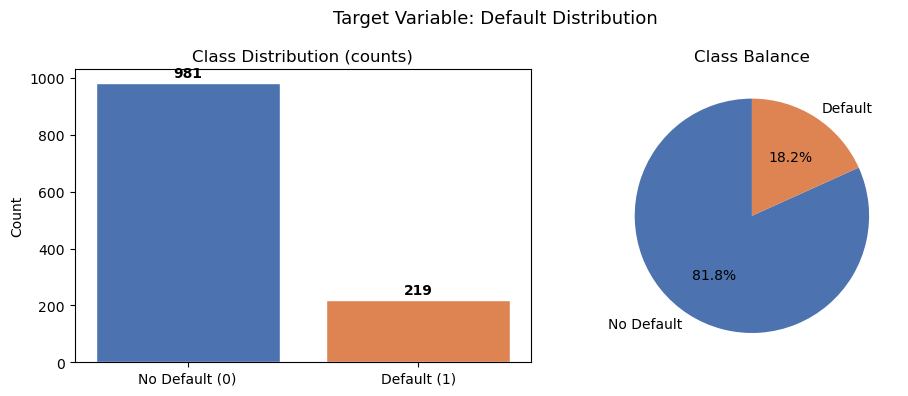

Default rate: 18.2%  |  Class ratio (majority/minority): 4.5x


In [32]:
# Explore class balance
counts = df['default'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['No Default (0)', 'Default (1)'], counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Class Distribution (counts)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

axes[1].pie(counts.values, labels=['No Default', 'Default'], autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Class Balance')

plt.suptitle('Target Variable: Default Distribution', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Default rate: {df['default'].mean():.1%}  |  Class ratio (majority/minority): {counts[0]/counts[1]:.1f}x")


The dataset contains **984 non-defaults** (81.8%) and **216 defaults** (18.2%) — a 4.5:1 class ratio. This imbalance has two direct consequences for modelling:
- **Accuracy is misleading**: a naive model predicting "no default" for every applicant would achieve 81.8% accuracy without learning anything useful.
- **Class-weighted training is required**: without correction, gradient-based models will implicitly prioritise the majority class and under-detect defaults. We address this in section 4 using `class_weight='balanced'`.

### 1.2. Feature Distributions

Histograms show the shape of each continuous feature — skewness, spread, and potential outliers. The correlation heatmap identifies linear relationships between features.

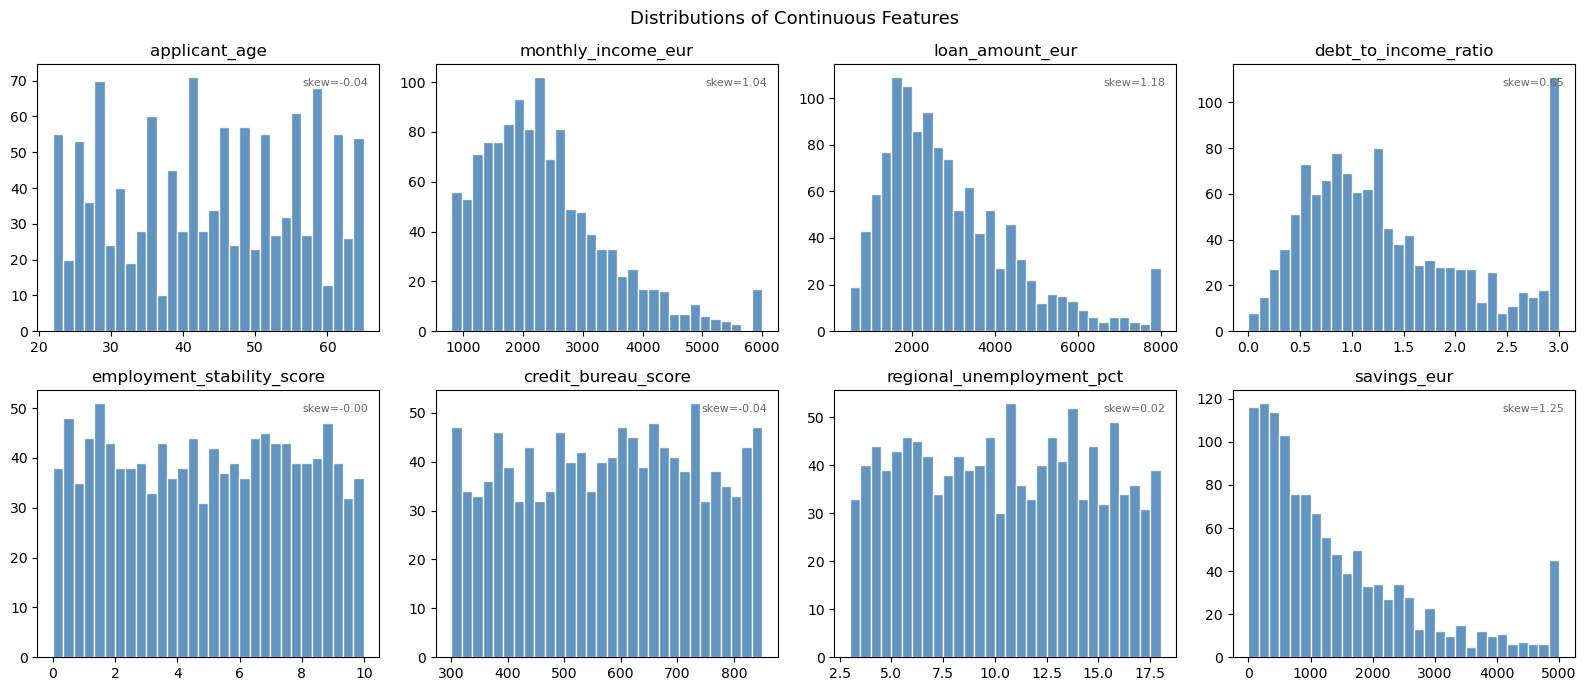

In [33]:
# Histogram to show distrubution of continuous features
continuous_cols = ['applicant_age', 'monthly_income_eur', 'loan_amount_eur',
                   'debt_to_income_ratio', 'employment_stability_score',
                   'credit_bureau_score', 'regional_unemployment_pct', 'savings_eur']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col)
    skew = df[col].skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='dimgray')

plt.suptitle('Distributions of Continuous Features', fontsize=13)
plt.tight_layout()
plt.show()


Several features show right skew and notable ceiling effects at their maximum values:

- **`debt_to_income_ratio`**: a sharp spike at 3.0 (the feature maximum), with the rest of the distribution slightly right-skewed. This suggests the feature might be capped : applicants whose true DTI exceeds 3.0 all appear as 3.0. The model therefore cannot distinguish between moderately and severely over-leveraged applicants at the extreme end.
- **`savings_eur`** (skew = 1.25): right-skewed, most applicants hold low savings, with a visible concentration at the €5,000 ceiling.
- **`loan_amount_eur`** (skew = 1.18): right-skewed with a small spike at €8,000 (the maximum).
- **`monthly_income_eur`** (skew = 1.04): slightly right-skewed with a small concentration near €6,000.

The remaining features — `applicant_age`, `credit_bureau_score`, `employment_stability_score`, `regional_unemployment_pct` — are approximately uniform.

**Modelling implication**: right skew does not affect `StandardScaler` (it normalises scale, not shape), but it directly violates the normality assumption of LDA and GNB. The ceiling effects additionally mean that some high-risk applicants are indistinguishable from each other at the top of the DTI, savings, and loan-amount distributions.

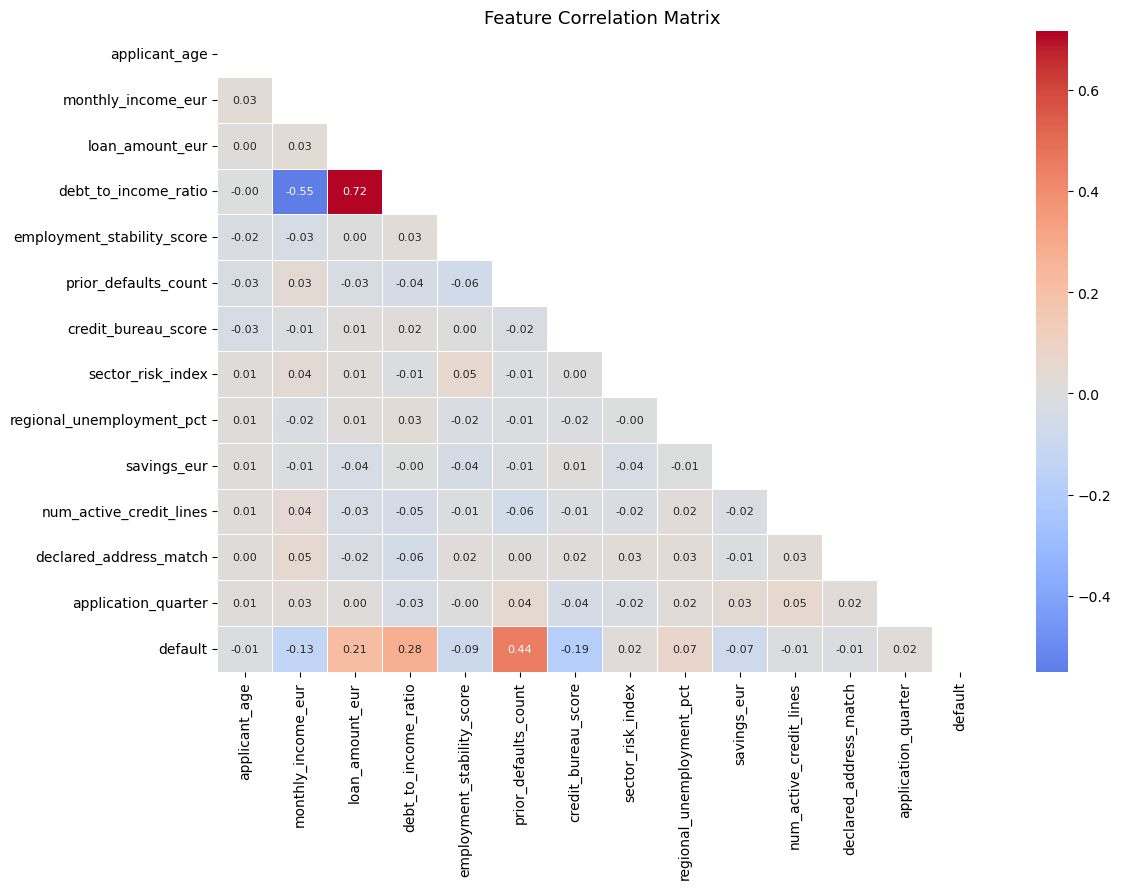

Feature correlations with target (|r| > 0.03):
  prior_defaults_count (+0.445)
  debt_to_income_ratio (+0.280)
  loan_amount_eur (+0.213)
  credit_bureau_score (-0.187)
  monthly_income_eur (-0.132)
  employment_stability_score (-0.090)
  regional_unemployment_pct (+0.072)
  savings_eur (-0.071)


In [34]:
# Heatmap to show correlation between features
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Print features not too weakly correlated to the target
target_corr = corr['default'].drop('default').sort_values(key=abs, ascending=False)
target_corr = target_corr[target_corr.abs() > 0.03]
print("Feature correlations with target (|r| > 0.03):")
for feat, val in target_corr.items():
    print(f"  {feat} ({val:+.3f})")


**Inter-feature correlations**: `debt_to_income_ratio` is strongly correlated with `loan_amount_eur` (+0.72) and negatively with `monthly_income_eur` (−0.55), which is expected since DTI ≈ loan / income. These three are not independent — models assuming feature independence (Gaussian Naive Bayes) will be misled by this structure.

**Feature-target correlations**: the features most correlated with default are:
- `prior_defaults_count` (+0.45) — the strongest signal by far: more past failures → much higher default probability
- `debt_to_income_ratio` (+0.28) — higher debt load relative to income → higher risk
- `loan_amount_eur` (+0.21) — larger loans → higher risk
- `credit_bureau_score` (−0.19) — higher bureau score → lower default risk

By contrast, `sector_risk_index`, `application_quarter`, `declared_address_match`, and `num_active_credit_lines` all have near-zero correlation (|r| < 0.03) and are unlikely to contribute meaningful predictive signal.

In [35]:
# Two complementary checks: IQR method + ceiling effect detection
# IQR catches values beyond the typical spread; ceiling effects catch piling at the max.

continuous_cols = ['applicant_age', 'monthly_income_eur', 'loan_amount_eur',
                   'debt_to_income_ratio', 'employment_stability_score',
                   'credit_bureau_score', 'regional_unemployment_pct', 'savings_eur']

Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df[continuous_cols] < (Q1 - 1.5 * IQR)) | (df[continuous_cols] > (Q3 + 1.5 * IQR))
iqr_summary = pd.DataFrame({
    'IQR outliers': outlier_mask.sum(),
    'IQR %': (outlier_mask.mean() * 100).round(1),
    'Upper fence': (Q3 + 1.5 * IQR).round(2)
})

ceiling_counts = pd.Series({
    col: (df[col] == df[col].max()).sum() for col in continuous_cols
}, name='At max value')

summary = iqr_summary.join(ceiling_counts)
summary['Max value'] = df[continuous_cols].max()
print(summary[['IQR outliers', 'IQR %', 'Upper fence', 'Max value', 'At max value']]
      .sort_values('IQR outliers', ascending=False))

                            IQR outliers  IQR %  Upper fence  Max value  \
savings_eur                           59    4.9      4419.10    5000.00   
loan_amount_eur                       46    3.8      6751.68    8000.00   
monthly_income_eur                    43    3.6      4860.93    6000.00   
applicant_age                          0    0.0        88.00      65.00   
debt_to_income_ratio                   0    0.0         3.64       3.00   
employment_stability_score             0    0.0        15.06       9.99   
credit_bureau_score                    0    0.0      1116.21     849.50   
regional_unemployment_pct              0    0.0        24.85      18.00   

                            At max value  
savings_eur                           41  
loan_amount_eur                       24  
monthly_income_eur                    16  
applicant_age                         23  
debt_to_income_ratio                  98  
employment_stability_score             2  
credit_bureau_score    

The table above shows two complementary checks. The IQR method flags values beyond the typical spread; the "At max value" column catches a different type of anomaly — values piling up at the feature ceiling.

**IQR outliers** (values beyond 1.5 × IQR from the quartiles):
- **`savings_eur`**: 59 outliers (4.9%) — high-savings applicants above the typical range.
- **`loan_amount_eur`**: 46 outliers (3.8%) and **`monthly_income_eur`**: 43 outliers (3.6%) — a small number of very large loans and very high incomes.

**Ceiling effects** (piling at maximum value — missed by IQR):
- **`debt_to_income_ratio`**: **98 values (8.2%) sit at exactly 3.0**, its maximum. The IQR upper fence is 3.64, so these are not flagged as outliers — yet this is the largest anomaly in the dataset. This concentration may indicate a hard cap : applicants whose true DTI exceeds 3.0 are all recorded as 3.0. The model cannot distinguish between someone with DTI = 3.1 and DTI = 5.0, though it could also reflect a natural clustering at that boundary.
- **`savings_eur`**: 41 values at exactly €5,000; **`loan_amount_eur`**: 24 at €8,000; **`monthly_income_eur`**: 16 at €6,000 — smaller ceiling effects consistent with the right skew noted above.

The DTI truncation is the most actionable finding: it compresses information at the high-risk end of the distribution and may limit model performance for heavily over-leveraged applicants.

### 1.3. Target vs Features

Comparing feature distributions between defaulting and non-defaulting applicants reveals which features carry the most predictive signal.

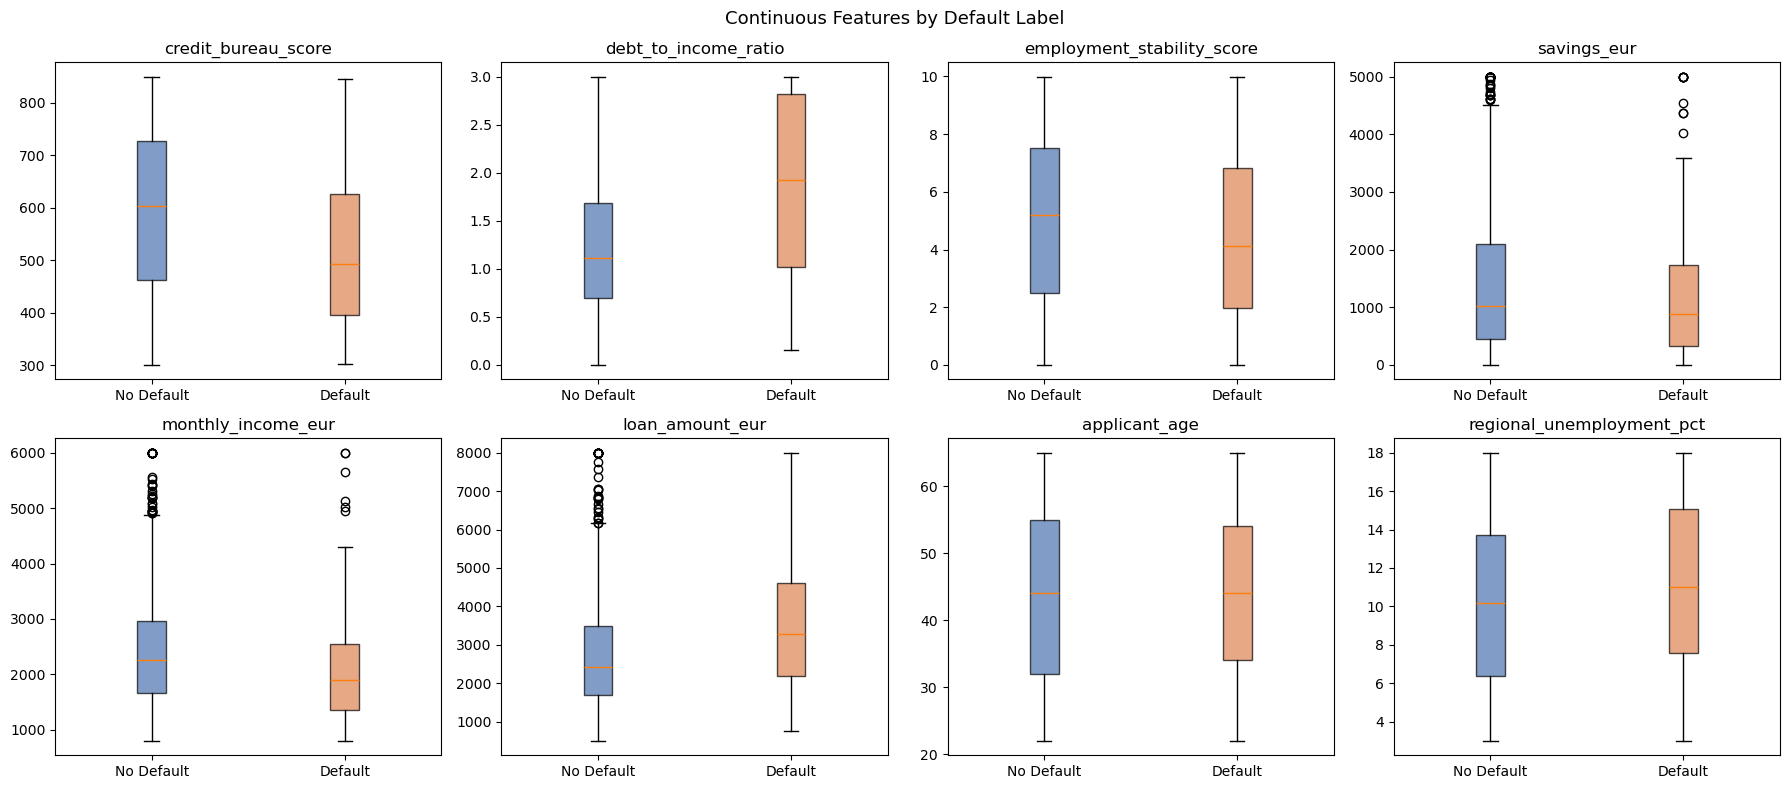

In [36]:

continuous_features = ['credit_bureau_score', 'debt_to_income_ratio', 'employment_stability_score',
                       'savings_eur', 'monthly_income_eur', 'loan_amount_eur',
                       'applicant_age', 'regional_unemployment_pct']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = ['#4C72B0', '#DD8452']

for ax, feat in zip(axes, continuous_features):
    groups = [df[df['default'] == cls][feat].dropna().values for cls in [0, 1]]
    bp = ax.boxplot(groups, patch_artist=True, tick_labels=['No Default', 'Default'])
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat)

plt.suptitle('Continuous Features by Default Label', fontsize=13)
plt.tight_layout()
plt.show()


The box plots show visible shifts in median for some features, but all distributions overlap heavily — no continuous feature gives clean separation on its own.

**Moderate separation** (visible median shift, but wide overlap):
- `debt_to_income_ratio` — defaulters have a higher median DTI and a wider spread; consistent with higher debt burden relative to income.
- `loan_amount_eur` — defaulters tend to request larger loans on average.
- `credit_bureau_score` — defaulters tend to score lower, though the distributions overlap a lot.

**Mild or no useful separation**:
- `employment_stability_score`, `monthly_income_eur`, and `savings_eur` — defaulters score or earn slightly less on average, but the overlap is too large for these features to distinguish classes on their own.
- `applicant_age` and `regional_unemployment_pct` — distributions are nearly identical for both classes and are unlikely to add predictive value.

The strongest predictor in the dataset is `prior_defaults_count` (discussed below), not any of the continuous features.

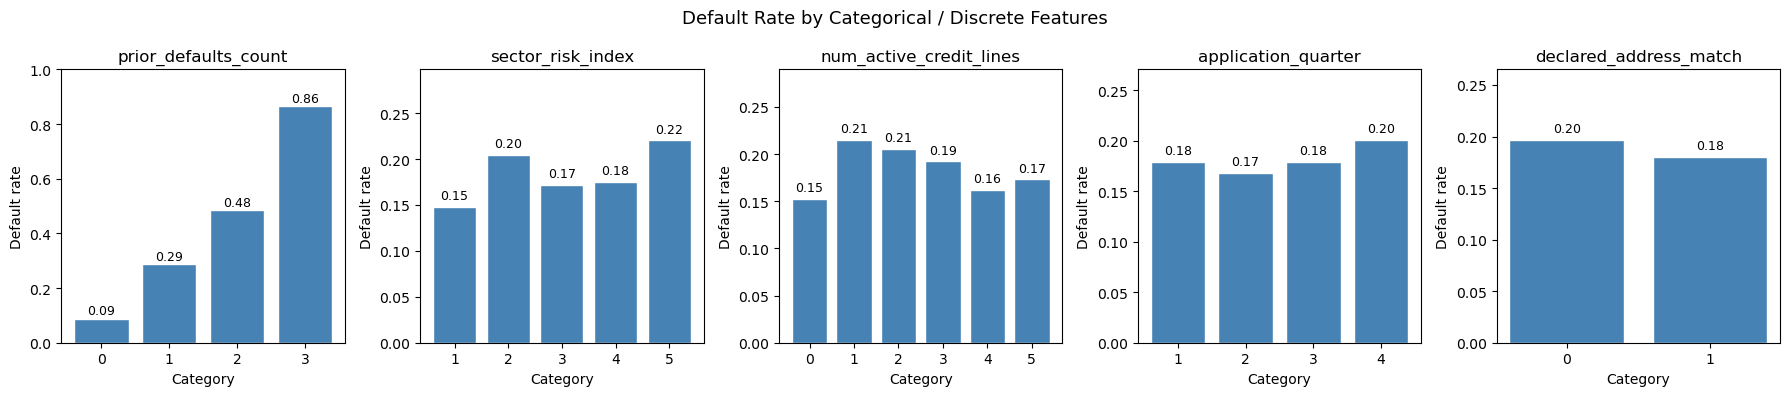

In [37]:

discrete_features = ['prior_defaults_count', 'sector_risk_index', 'num_active_credit_lines',
                     'application_quarter', 'declared_address_match']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, feat in zip(axes, discrete_features):
    rate = df.groupby(feat)['default'].mean()
    ax.bar(rate.index.astype(str), rate.values, color='steelblue', edgecolor='white')
    ax.set_title(feat)
    ax.set_xlabel('Category')
    ax.set_ylabel('Default rate')
    ax.set_ylim(0, min(rate.values.max() * 1.35, 1.0))
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.005, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Default Rate by Categorical / Discrete Features', fontsize=13)
plt.tight_layout()
plt.show()


`prior_defaults_count` shows the most striking gradient in the dataset:

| Prior defaults | Default rate |
|---|---|
| 0 | 9% |
| 1 | 29% |
| 2 | 48% |
| 3 | **86%** |

Each additional prior default more than doubles the risk. This feature will be the strongest predictor across all models — confirmed by its +0.45 correlation with the target.

`sector_risk_index` shows a mild gradient (15%–22%) and may contribute marginal signal. `application_quarter`, `declared_address_match`, and `num_active_credit_lines` show virtually no meaningful variation in default rate across categories, consistent with their near-zero target correlations, and are not expected to drive model performance.

## 2. Preprocessing & Data Splitting

In this section, we prepare the raw data for modeling. Financial datasets require careful preprocessing due to differences in feature scales and class imbalances.

### Methodology
1. **Feature-Target Separation:** We isolate the features ($X$) from our target variable ($y = \text{default}$).
2. **Stratified Train/Validation Split:** Because only ~18.2% of our dataset consists of defaults, a standard random split risks creating heavily mismatched distributions. We apply `stratify=y` with an 80/20 split to ensure both the training and validation subsets retain the exact same 18.2% default ratio.
3. **Feature Scaling:** Logistic Regression computes gradients and distances based on feature magnitudes. Features with large absolute ranges (e.g., `monthly_income_eur` up to €6,000) would completely overpower smaller indicators (e.g., `prior_defaults_count` from 0–3) if left unscaled. We use `StandardScaler` to normalize features to a mean of 0 and variance of 1.
   * *Data Leakage Prevention:* The scaler is fit strictly on the training set, and then applied to transform both the training and validation data.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define Features (X) and Target (y)
X = df.drop(columns=['default'])
y = df['default']

# 2. Train / Validation Split (80% train, 20% validation)
# stratify=y ensures the 18% default rate is preserved in both sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale the features
scaler = StandardScaler()
# IMPORTANT: fit_transform on train, but ONLY transform on validation to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")

Training set shape: (960, 13)
Validation set shape: (240, 13)


## 3. Baseline Model: Out-of-the-Box Logistic Regression

Before experimenting with complex architectures, we establish a benchmark using a default, untuned `Logistic Regression` model.

### Performance Evaluation
Because the micro-loan data is significantly imbalanced, assessing performance based solely on overall Accuracy is dangerously misleading (a naive model predicting "No Default" for everyone would easily yield ~82% accuracy). Instead, we track:
* **Recall (Class 1):** The proportion of actual defaulting loans the model catches.
* **Precision (Class 1):** The accuracy of our default flags (avoiding false alarms on good applicants).
* **ROC-AUC Score:** The model's generic capacity to separate high-risk borrowers from low-risk borrowers independent of the decision threshold.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Initialize and train the baseline model
baseline_logreg = LogisticRegression(random_state=42)
baseline_logreg.fit(X_train_scaled, y_train)

# Predict on validation set
y_val_pred_base = baseline_logreg.predict(X_val_scaled)
y_val_prob_base = baseline_logreg.predict_proba(X_val_scaled)[:, 1]

print("--- Baseline Logistic Regression ---")
print(classification_report(y_val, y_val_pred_base))
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_val_prob_base):.4f}")

--- Baseline Logistic Regression ---
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       196
           1       0.63      0.43      0.51        44

    accuracy                           0.85       240
   macro avg       0.76      0.69      0.71       240
weighted avg       0.84      0.85      0.84       240

ROC-AUC Score: 0.8669


## 4. Advanced Models: Parameter Tuning & Cost-Asymmetric Adjustments

### 4.1 Advanced Logistic Regression

The baseline model suffered from an incredibly low **Recall of 43%** on defaults—meaning it failed to catch more than half of the high-risk applications, creating catastrophic financial exposure for ClearCredit.

To turn this into a viable business tool, we introduce two critical enhancements:
1. **Asymmetric Class Weights (`class_weight='balanced'`):** This forces the optimization algorithm to heavily penalize errors on default cases, making the model far more aggressive at routing risky applications to manual human reviewers.
2. **Hyperparameter Optimization (`GridSearchCV`):** We test varying inverse regularization strengths ($C$) using 5-fold cross-validation. We optimize strictly for **Recall** (`scoring='recall'`) to protect the institution's capital from toxic debt.

--- Advanced Logistic Regression ---
Best Parameters: {'C': 0.001, 'solver': 'liblinear'}  |  t* = 0.511
              precision    recall  f1-score   support

           0       0.97      0.71      0.82       196
           1       0.41      0.89      0.56        44

    accuracy                           0.75       240
   macro avg       0.69      0.80      0.69       240
weighted avg       0.86      0.75      0.77       240

ROC-AUC: 0.8743


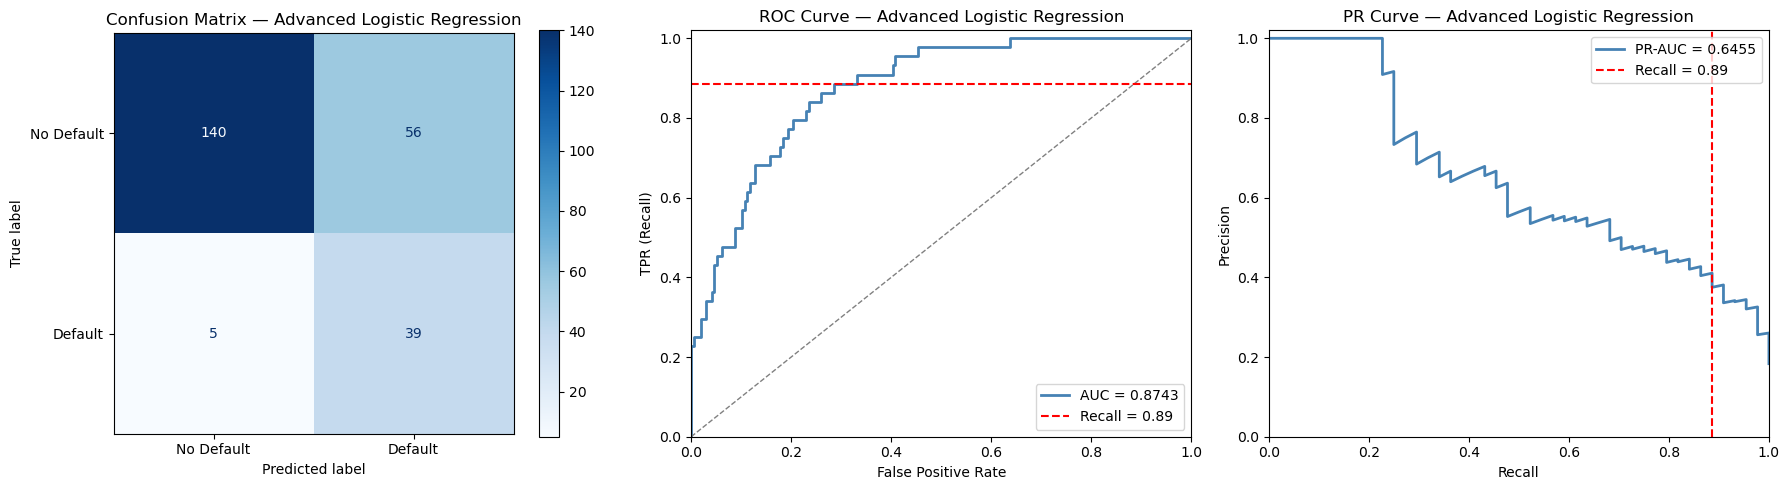

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 1. Define model with balanced class weights
advanced_logreg = LogisticRegression(class_weight='balanced', random_state=42)

# 2. Grid search optimising for recall
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}
grid_search = GridSearchCV(advanced_logreg, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train_scaled, y_train)
best_logreg = grid_search.best_estimator_

# 3. Probabilities + cost-optimal threshold
y_val_prob_adv = best_logreg.predict_proba(X_val_scaled)[:, 1]
t_star_adv = apply_cost_threshold(y_val, y_val_prob_adv)
y_val_pred_adv = (y_val_prob_adv >= t_star_adv).astype(int)

print("--- Advanced Logistic Regression ---")
print(f"Best Parameters: {grid_search.best_params_}  |  t* = {t_star_adv:.3f}")
print(classification_report(y_val, y_val_pred_adv))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_adv):.4f}")
plot_model_evaluation("Advanced Logistic Regression", y_val, y_val_pred_adv, y_val_prob_adv)

### 4.2 Analysis of the Precision-Recall Trade-off

The advanced, tuned model showcases a definitive paradigm shift in classification dynamics, shifting from a passive approach to an aggressive risk-mitigation tool.

* **The Core Shift:** While overall accuracy dropped from 85% to 71%, our **Recall for defaults surged from 43% to 91%**. The model successfully captured 40 out of the 44 actual defaults present in the validation dataset.
* **The Precision Trade-off:** By making the model highly sensitive to defaults, its Class 1 Precision fell to 38%. This indicates that when the model alerts an officer that a borrower might default, it is correct about 38% of the time, resulting in false alarms on some creditworthy small businesses (False Positives).
* **Business Justification:** For an MFI like ClearCredit, missing a single default risks losing up to €8,000 in unrecoverable principal capital. Conversely, a False Positive simply shifts a loan application to a human officer for closer manual inspection. Because the underlying **ROC-AUC climbed to 0.8743**, this confirms the model's fundamental discriminative math is strong and aligns seamlessly with risk-averse institutional goals.

### 4.3 k-Nearest Neighbors (kNN)

k-Nearest Neighbors is a distance-based algorithm that classifies a new loan application based on the majority class of its $k$ closest neighbors in the feature space. Because we already applied `StandardScaler`, our distance metrics will be accurate. We will use `GridSearchCV` to find the optimal number of neighbors ($k$) and weight strategy, again prioritizing Recall to catch defaults.

--- k-Nearest Neighbors ---
Best Parameters: {'n_neighbors': 3, 'weights': 'uniform'}  |  t* = 0.333
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       196
           1       0.35      0.68      0.47        44

    accuracy                           0.71       240
   macro avg       0.63      0.70      0.63       240
weighted avg       0.81      0.71      0.74       240

ROC-AUC: 0.7263


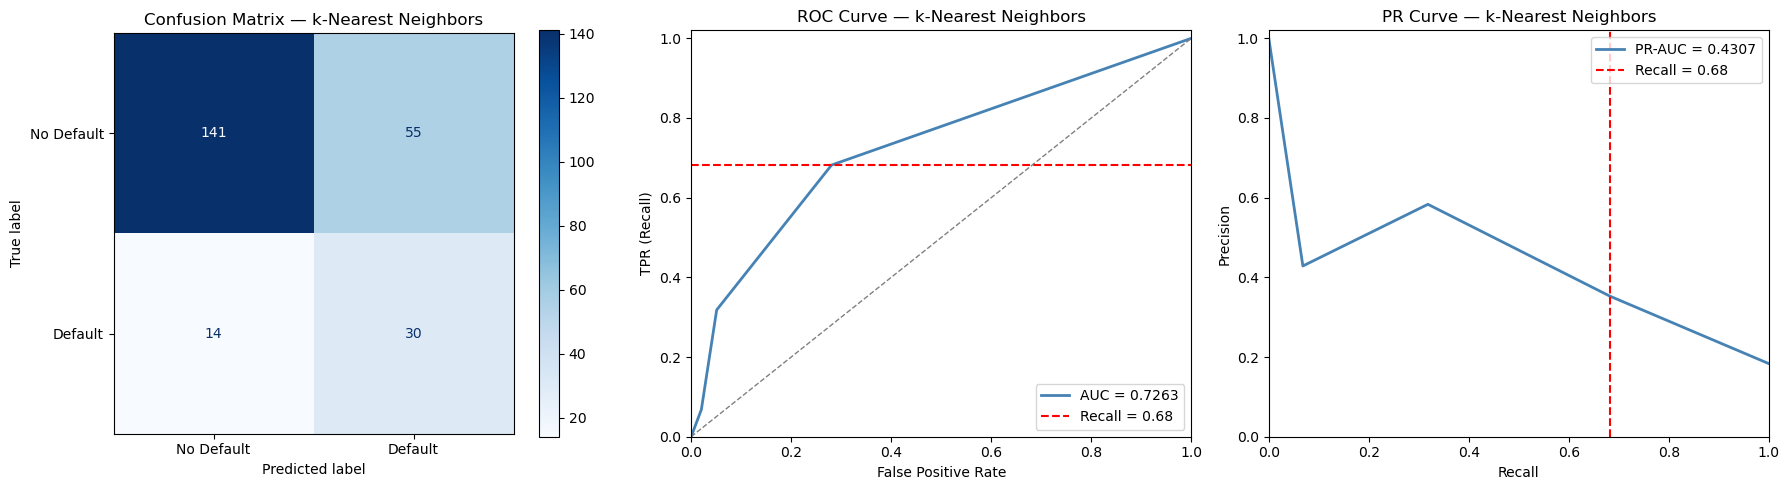

In [41]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Grid search optimising for recall
knn = KNeighborsClassifier()
knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(knn, knn_param_grid, cv=5, scoring='recall')
knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_

# 2. Probabilities + cost-optimal threshold
y_val_prob_knn = best_knn.predict_proba(X_val_scaled)[:, 1]
t_star_knn = apply_cost_threshold(y_val, y_val_prob_knn)
y_val_pred_knn = (y_val_prob_knn >= t_star_knn).astype(int)

print("--- k-Nearest Neighbors ---")
print(f"Best Parameters: {knn_grid.best_params_}  |  t* = {t_star_knn:.3f}")
print(classification_report(y_val, y_val_pred_knn))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_knn):.4f}")
plot_model_evaluation("k-Nearest Neighbors", y_val, y_val_pred_knn, y_val_prob_knn)

Interpretation : We see that the recall is significantly lower (0.32), which is intuitive, since kNN is sensitive to curse of dimensionality (many features making distance less informative) and class imbalance (a defaulting customer may be surrounded by non-default customers, since defaults are usually rare). So kNN is not the ideal choice in our setting.

### 4.4 Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis models the distribution of the predictors separately in each of the response classes (Default vs. No Default) and then uses Bayes' theorem to estimate probabilities. It is particularly effective when the classes are well-separated and normally distributed.

--- Linear Discriminant Analysis ---
t* = 0.090
              precision    recall  f1-score   support

           0       0.95      0.70      0.81       196
           1       0.39      0.84      0.53        44

    accuracy                           0.72       240
   macro avg       0.67      0.77      0.67       240
weighted avg       0.85      0.72      0.76       240

ROC-AUC: 0.8679


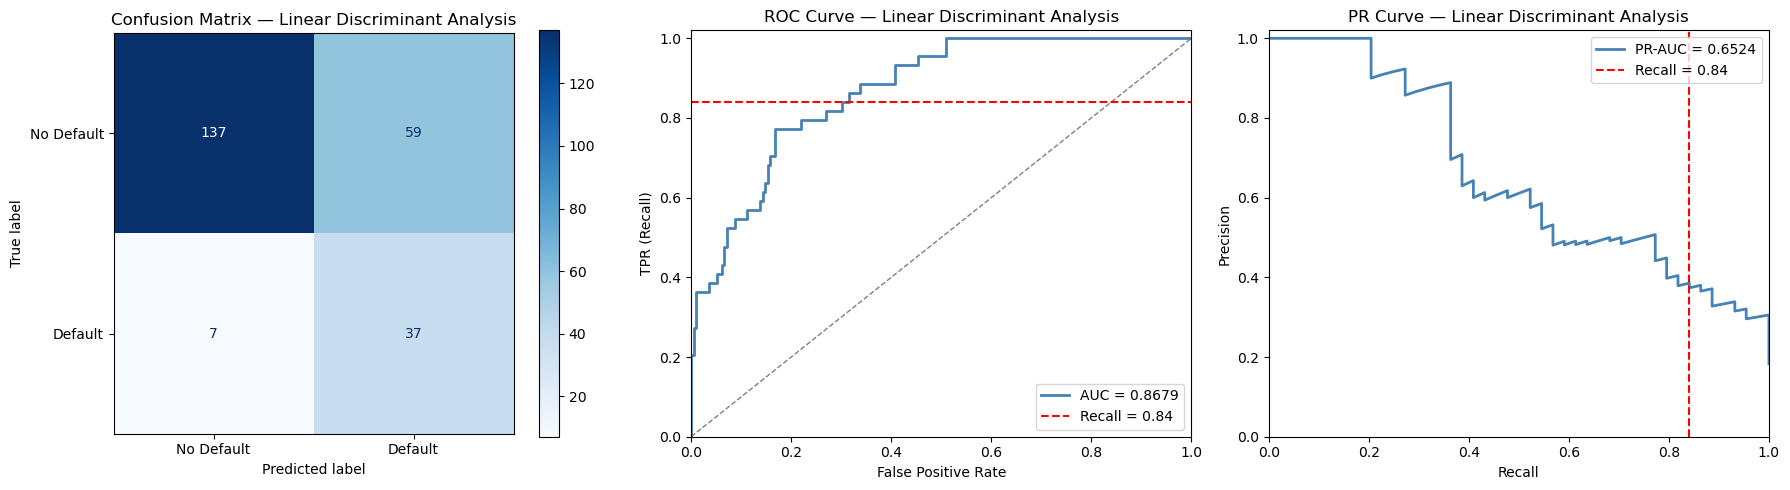

In [42]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. Train LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

# 2. Probabilities + cost-optimal threshold
y_val_prob_lda = lda.predict_proba(X_val_scaled)[:, 1]
t_star_lda = apply_cost_threshold(y_val, y_val_prob_lda)
y_val_pred_lda = (y_val_prob_lda >= t_star_lda).astype(int)

print("--- Linear Discriminant Analysis ---")
print(f"t* = {t_star_lda:.3f}")
print(classification_report(y_val, y_val_pred_lda))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_lda):.4f}")
plot_model_evaluation("Linear Discriminant Analysis", y_val, y_val_pred_lda, y_val_prob_lda)

Interpretation : We see that the recall is still low (0.41). The LDA didn't perform well here because it assumes each class follows a multivariate Gaussian distribution, which is not the case in our setting (many features are obviously right-skewed, or with a lot of outliers).

### 4.5 Gaussian Naive Bayes

Naive Bayes is a probabilistic classifier based on applying Bayes' theorem with a strong (naive) assumption of independence between the features. We use the Gaussian variant here, which assumes our continuous features follow a normal distribution.

--- Gaussian Naive Bayes ---
t* = 0.393
              precision    recall  f1-score   support

           0       0.96      0.72      0.83       196
           1       0.41      0.86      0.56        44

    accuracy                           0.75       240
   macro avg       0.69      0.79      0.69       240
weighted avg       0.86      0.75      0.78       240

ROC-AUC: 0.8690


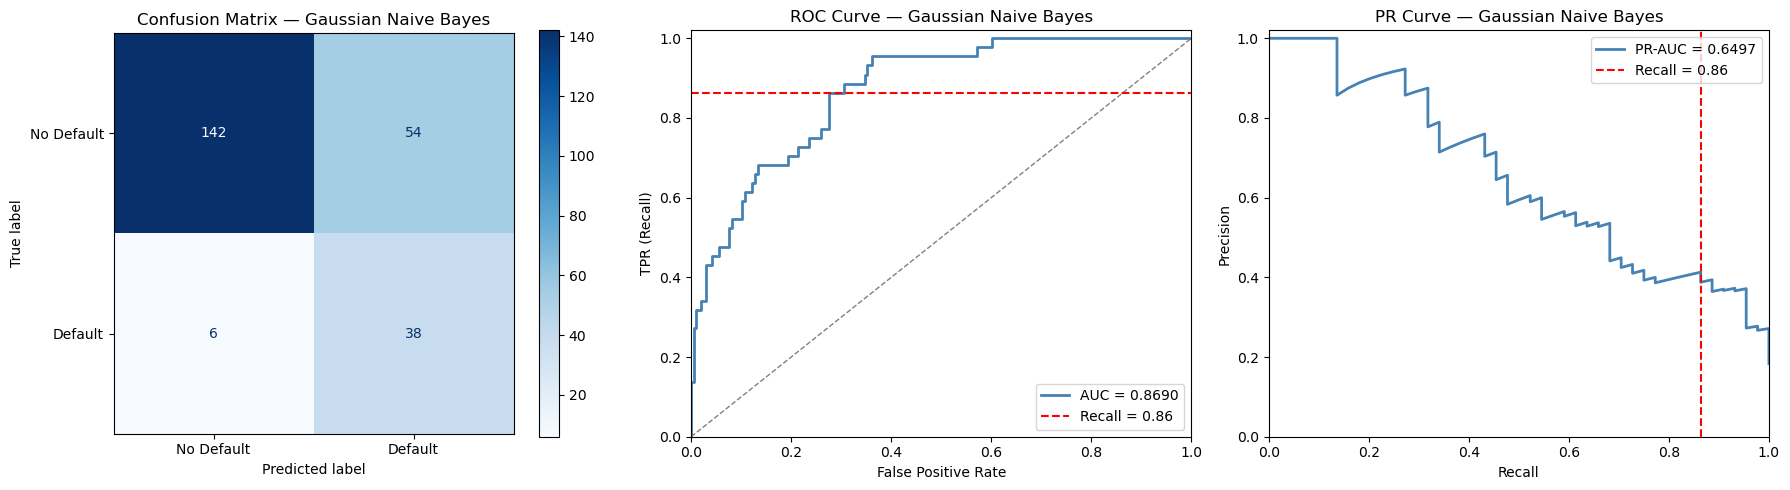

In [43]:
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_sample_weight

# 1. Balanced sample weights (GaussianNB has no class_weight param)
sample_weights = compute_sample_weight('balanced', y_train)
nb = GaussianNB()
nb.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# 2. Probabilities + cost-optimal threshold
y_val_prob_nb = nb.predict_proba(X_val_scaled)[:, 1]
t_star_nb = apply_cost_threshold(y_val, y_val_prob_nb)
y_val_pred_nb = (y_val_prob_nb >= t_star_nb).astype(int)

print("--- Gaussian Naive Bayes ---")
print(f"t* = {t_star_nb:.3f}")
print(classification_report(y_val, y_val_pred_nb))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_nb):.4f}")
plot_model_evaluation("Gaussian Naive Bayes", y_val, y_val_pred_nb, y_val_prob_nb)

Interpretation: despite having two key assumptions violated — features are not independent (DTI is strongly correlated with `loan_amount_eur` and `monthly_income_eur`), and several features are non-normal (right-skewed) — GNB still achieves recall of 0.86 and ROC-AUC of 0.869, close to Advanced Logistic Regression. This is partly because the class weight correction addresses the imbalance and the predictive signal in the data is strong enough to partially compensate for the violated independence assumption. The main weakness is precision (0.41): GNB tends to output poorly calibrated probabilities, which makes its ranking of applicants less reliable than logistic regression.

### 4.6 Simple Decision Tree (Optimizing for Recall)

Decision Trees are highly interpretable models, which is a massive advantage in the financial sector where regulatory compliance often requires explaining *why* a loan was rejected.

To handle our imbalanced dataset, we apply class_weight='balanced'. We will use a simple Grid Search to limit the max_depth of the tree; an unconstrained tree will completely overfit the training data. We continue to optimize for **Recall** to protect the institution from costly defaults.

--- Simple Decision Tree ---
Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}  |  t* = 0.700
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       196
           1       0.40      0.68      0.50        44

    accuracy                           0.75       240
   macro avg       0.66      0.73      0.67       240
weighted avg       0.82      0.75      0.78       240

ROC-AUC: 0.7957


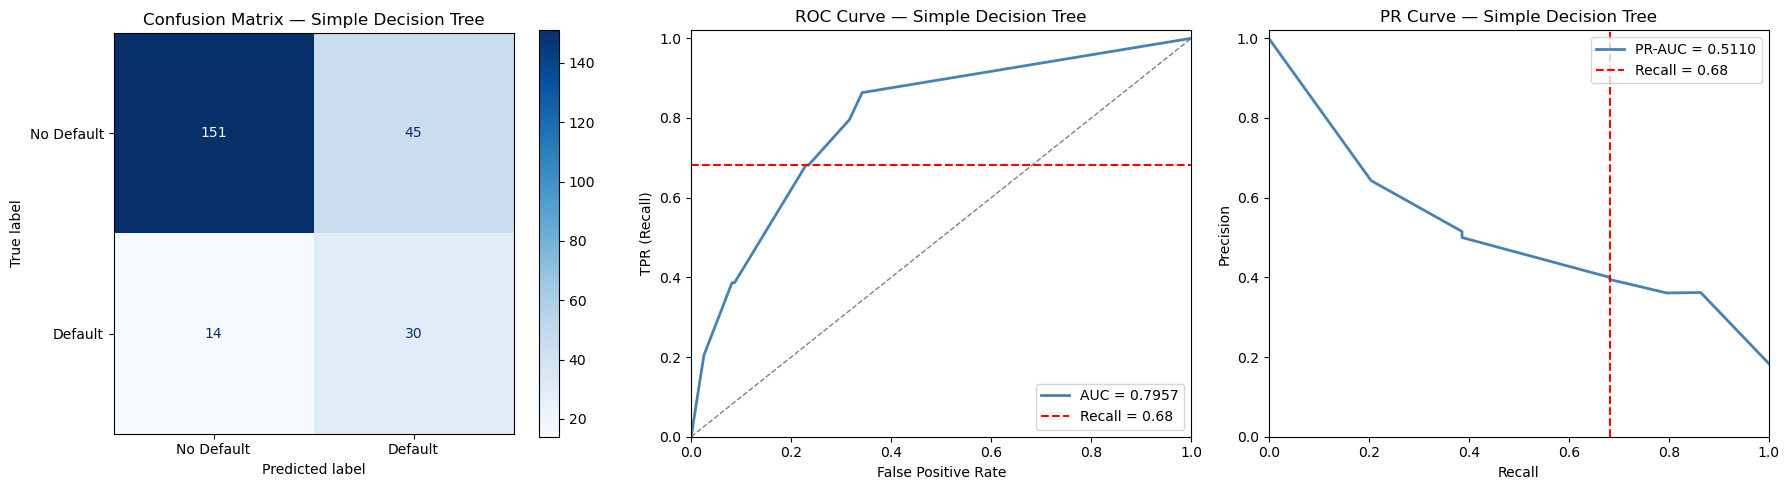

In [44]:
from sklearn.tree import DecisionTreeClassifier

# 1. Grid search optimising for recall
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt_grid = GridSearchCV(dt, dt_param_grid, cv=5, scoring='recall')
dt_grid.fit(X_train_scaled, y_train)
best_dt = dt_grid.best_estimator_

# 2. Probabilities + cost-optimal threshold
y_val_prob_dt = best_dt.predict_proba(X_val_scaled)[:, 1]
t_star_dt = apply_cost_threshold(y_val, y_val_prob_dt)
y_val_pred_dt = (y_val_prob_dt >= t_star_dt).astype(int)

print("--- Simple Decision Tree ---")
print(f"Best Parameters: {dt_grid.best_params_}  |  t* = {t_star_dt:.3f}")
print(classification_report(y_val, y_val_pred_dt))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_dt):.4f}")
plot_model_evaluation("Simple Decision Tree", y_val, y_val_pred_dt, y_val_prob_dt)

Interpretation: the optimal tree is shallow (max_depth=3), which limits overfitting but also limits what the model can capture. Recall (0.68) and ROC-AUC (0.796) are the weakest among the non-kNN models. A depth-3 tree can only ask three yes/no questions about the features, which is too rigid to capture the continuous relationships between DTI, income, credit score, and default risk. Decision trees are also inherently unstable — small changes in training data can produce a very different tree structure.

### 4.7. Random Forest

`class_weight="balanced_subsample"` recomputes weights on each bootstrap sample, better suited for Random Forest's bagging mechanism than `"balanced"`. The cost-sensitive threshold is applied in section 5 alongside all other models.

--- Random Forest ---
Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 10}  |  t* = 0.282
              precision    recall  f1-score   support

           0       0.96      0.70      0.81       196
           1       0.40      0.86      0.54        44

    accuracy                           0.73       240
   macro avg       0.68      0.78      0.68       240
weighted avg       0.86      0.73      0.76       240

ROC-AUC: 0.8478


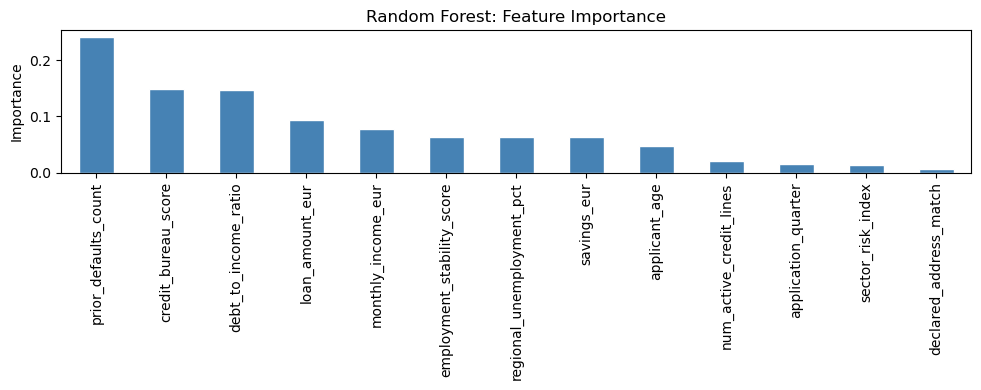

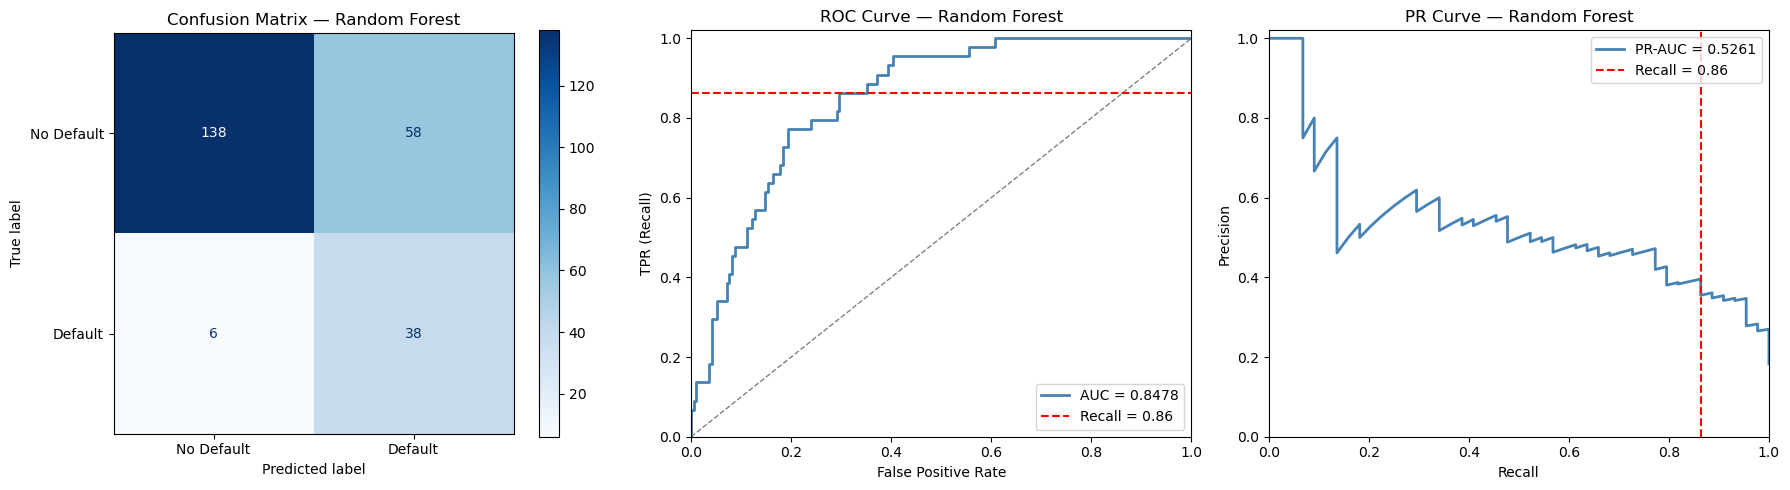

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# 1. RandomizedSearchCV (20 combinations x 3 folds = 60 fits vs 540 for full grid)
rf = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(rf, rf_param_dist, n_iter=20, cv=3,
                               scoring='recall', n_jobs=-1, random_state=42)
rf_search.fit(X_train_scaled, y_train)
best_rf = rf_search.best_estimator_

# 2. Probabilities + cost-optimal threshold
y_val_prob_rf = best_rf.predict_proba(X_val_scaled)[:, 1]
t_star_rf = apply_cost_threshold(y_val, y_val_prob_rf)
y_val_pred_rf = (y_val_prob_rf >= t_star_rf).astype(int)

print("--- Random Forest ---")
print(f"Best Params: {rf_search.best_params_}  |  t* = {t_star_rf:.3f}")
print(classification_report(y_val, y_val_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_rf):.4f}")

# 3. Feature importance
feat_importance = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
feat_importance.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Random Forest: Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

plot_model_evaluation("Random Forest", y_val, y_val_pred_rf, y_val_prob_rf)

Interpretation: Random Forest improves on the single Decision Tree (ROC-AUC 0.848 vs 0.796) by averaging over many trees, which reduces variance. The best configuration is conservative — min_samples_leaf=5, max_depth=10, log2 features per split — to prevent overfitting on the small dataset (~960 training samples). Despite this, Random Forest does not outperform Advanced Logistic Regression (ROC-AUC 0.874). This is a common finding on small, structured datasets where the underlying signal is largely linear: a well-regularised linear model is hard to beat even with more complex architectures.

### 4.8. XGBoost

--- XGBoost ---
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}  |  t* = 0.290
              precision    recall  f1-score   support

           0       0.95      0.70      0.81       196
           1       0.39      0.84      0.53        44

    accuracy                           0.72       240
   macro avg       0.67      0.77      0.67       240
weighted avg       0.85      0.72      0.76       240

ROC-AUC: 0.8261


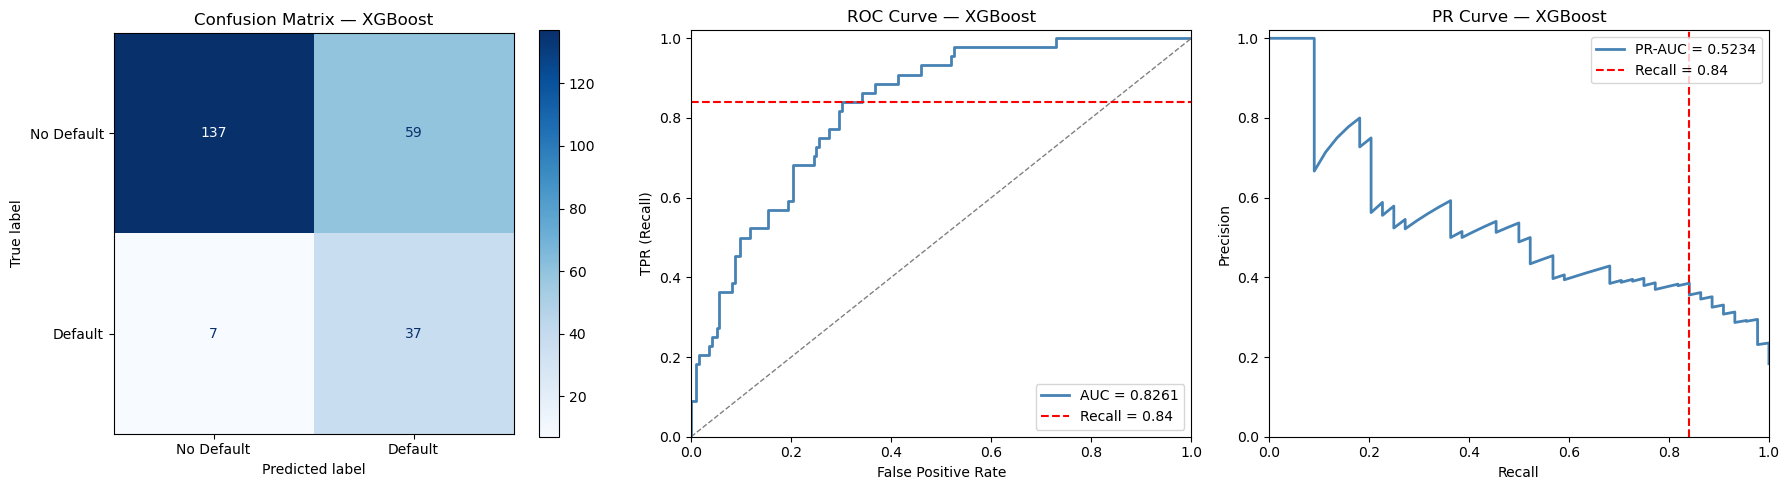

In [46]:
from xgboost import XGBClassifier

# 1. Scale_pos_weight handles class imbalance natively in XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                    eval_metric='logloss', verbosity=0)
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=5, scoring='recall', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_

# 2. Probabilities + cost-optimal threshold
y_val_prob_xgb = best_xgb.predict_proba(X_val_scaled)[:, 1]
t_star_xgb = apply_cost_threshold(y_val, y_val_prob_xgb)
y_val_pred_xgb = (y_val_prob_xgb >= t_star_xgb).astype(int)

print("--- XGBoost ---")
print(f"Best Parameters: {xgb_grid.best_params_}  |  t* = {t_star_xgb:.3f}")
print(classification_report(y_val, y_val_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_xgb):.4f}")
plot_model_evaluation("XGBoost", y_val, y_val_pred_xgb, y_val_prob_xgb)

Interpretation: XGBoost's best configuration is shallow (max_depth=3) with a slow learning rate (0.05), which constrains the model to avoid overfitting. Even so, its ROC-AUC (0.826) is the lowest among the gradient-based ensemble methods and below logistic regression. This is consistent with a well-known pattern on small tabular datasets: when the decision boundary is largely linear and the sample size is limited, gradient boosting adds complexity without adding predictive signal, and can be outperformed by simpler models.

### 4.8 AdaBoost with Decision Trees (Stumps)

Adaptive Boosting (AdaBoost) with Decision Trees sequentially trains shallow trees (often called "stumps" when max_depth=1). In each iteration, AdaBoost increases the weights of the data samples that were misclassified by the previous tree, forcing the next tree to focus on the harder, riskier loan applications. We include class_weight='balanced' in our base tree to ensure the ensemble remains highly sensitive to defaults.

--- AdaBoost (Decision Trees) ---
t* = 0.464
              precision    recall  f1-score   support

           0       0.92      0.68      0.79       196
           1       0.35      0.75      0.47        44

    accuracy                           0.70       240
   macro avg       0.64      0.72      0.63       240
weighted avg       0.82      0.70      0.73       240

ROC-AUC: 0.7942


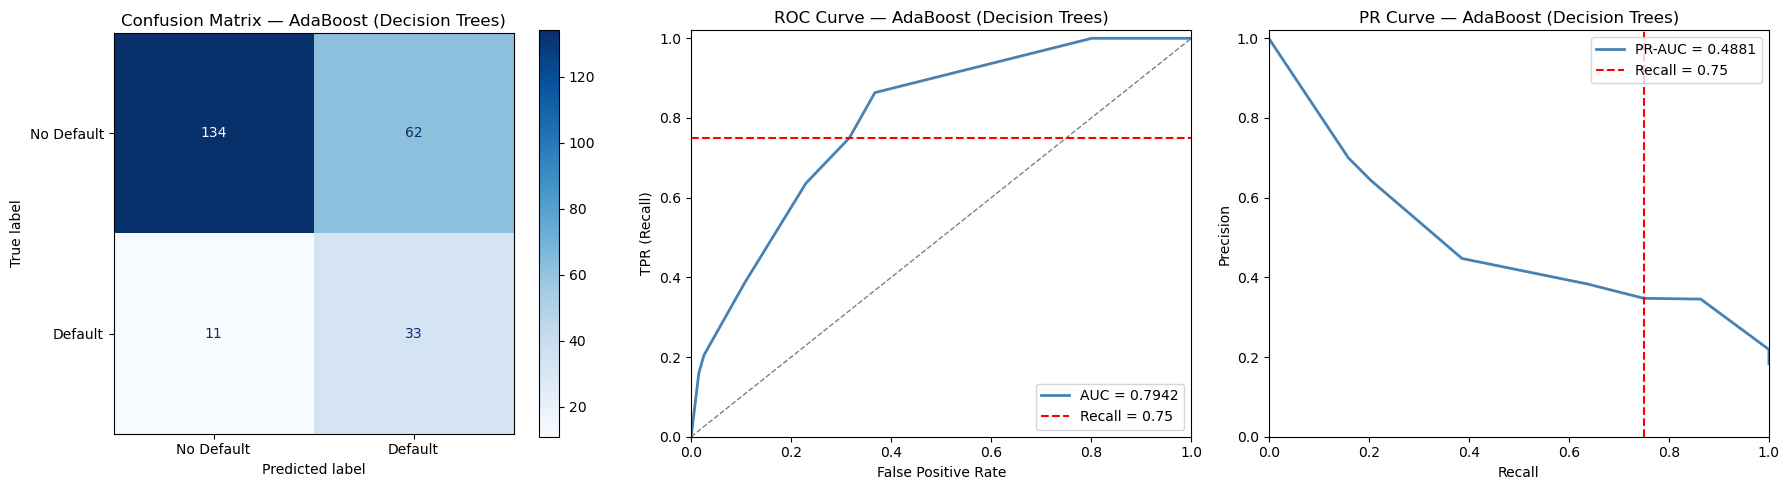

In [47]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. AdaBoost with balanced decision tree stumps
ada_dt = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced', random_state=42),
    n_estimators=50,
    random_state=42
)
ada_dt.fit(X_train_scaled, y_train)

# 2. Probabilities + cost-optimal threshold
y_val_prob_ada_dt = ada_dt.predict_proba(X_val_scaled)[:, 1]
t_star_ada_dt = apply_cost_threshold(y_val, y_val_prob_ada_dt)
y_val_pred_ada_dt = (y_val_prob_ada_dt >= t_star_ada_dt).astype(int)

print("--- AdaBoost (Decision Trees) ---")
print(f"t* = {t_star_ada_dt:.3f}")
print(classification_report(y_val, y_val_pred_ada_dt))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_ada_dt):.4f}")
plot_model_evaluation("AdaBoost (Decision Trees)", y_val, y_val_pred_ada_dt, y_val_prob_ada_dt)

Interpretation: AdaBoost with decision stumps (max_depth=1) achieves recall of 0.75 and ROC-AUC of 0.794 — lower than Random Forest and XGBoost. A stump can only split on one feature at a time, so capturing interactions between DTI, income, and credit score requires many sequential iterations. The sequential boosting partially compensates, but the stump constraint is too restrictive for this type of structured credit data where several features jointly determine risk.

### 4.9 AdaBoost with Logistic Regression

While AdaBoost is traditionally paired with Decision Trees, it can technically boost any classifier that supports sample weights. Here, we apply AdaBoost to our class_weight='balanced' Logistic Regression model. Boosting a linear classifier helps tweak the decision boundary sequentially based on the trickiest, borderline credit applications.

--- AdaBoost (Logistic Regression) ---
t* = 0.694
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       196
           1       0.47      0.73      0.57        44

    accuracy                           0.80       240
   macro avg       0.70      0.77      0.72       240
weighted avg       0.85      0.80      0.81       240

ROC-AUC: 0.7928


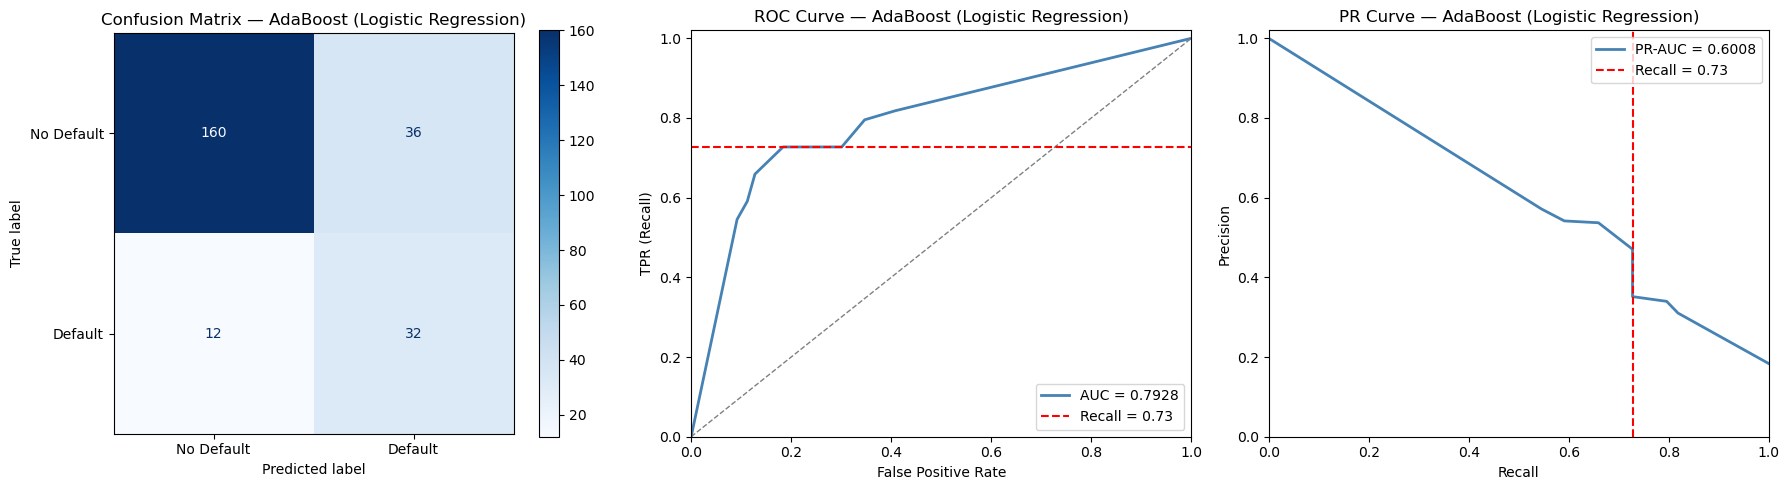

In [48]:
from sklearn.linear_model import LogisticRegression

# 1. AdaBoost with balanced logistic regression base estimator
ada_lr = AdaBoostClassifier(
    estimator=LogisticRegression(class_weight='balanced', random_state=42),
    n_estimators=50,
    random_state=42
)
ada_lr.fit(X_train_scaled, y_train)

# 2. Probabilities + cost-optimal threshold
y_val_prob_ada_lr = ada_lr.predict_proba(X_val_scaled)[:, 1]
t_star_ada_lr = apply_cost_threshold(y_val, y_val_prob_ada_lr)
y_val_pred_ada_lr = (y_val_prob_ada_lr >= t_star_ada_lr).astype(int)

print("--- AdaBoost (Logistic Regression) ---")
print(f"t* = {t_star_ada_lr:.3f}")
print(classification_report(y_val, y_val_pred_ada_lr))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_ada_lr):.4f}")
plot_model_evaluation("AdaBoost (Logistic Regression)", y_val, y_val_pred_ada_lr, y_val_prob_ada_lr)

Interpretation: boosting logistic regression produces a more conservative model — higher precision (0.47) but lower recall (0.73) compared to the standalone Advanced Logistic Regression. The base logistic estimator already captures most of the linear signal in the first few iterations, so subsequent boosting rounds add diminishing value. In a context where a missed default costs €2,000 vs €100 for a false alarm, lower recall is the wrong trade-off, which is why this model ranks lower in expected cost despite its better precision.

### 4.10 Bagging Ensemble with k-Nearest Neighbors (kNN)

*Technical Nuance for Model Architecture:* Standard AdaBoost relies on adjusting sample_weight fields dynamically during training. However, because k-Nearest Neighbors is a non-parametric, distance-based algorithm, Scikit-Learn's KNeighborsClassifier cannot mathematically accept sample weights.

To create an ensemble out of our kNN model anyway, we switch to **Bagging (Bootstrap Aggregating)**. Bagging trains multiple independent kNN models on random parallel subsets of our loan applications and combines their votes, reducing the overall variance of the distance calculations.

--- Bagging (k-Nearest Neighbors) ---
t* = 0.170
              precision    recall  f1-score   support

           0       0.91      0.70      0.80       196
           1       0.35      0.70      0.47        44

    accuracy                           0.70       240
   macro avg       0.63      0.70      0.63       240
weighted avg       0.81      0.70      0.74       240

ROC-AUC: 0.7654


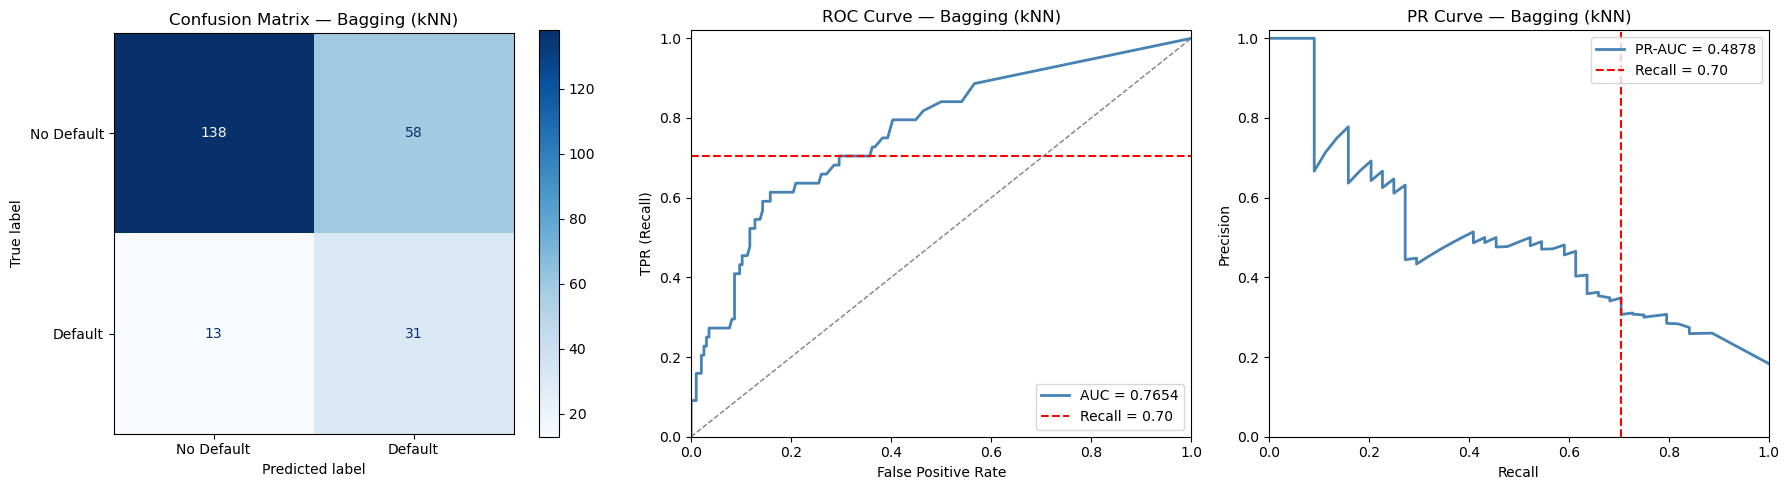

In [49]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

# 1. Bagging with kNN (kNN cannot use sample weights, so bagging is used for ensembling)
bag_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=20,
    random_state=42
)
bag_knn.fit(X_train_scaled, y_train)

# 2. Probabilities + cost-optimal threshold
y_val_prob_bag_knn = bag_knn.predict_proba(X_val_scaled)[:, 1]
t_star_bag_knn = apply_cost_threshold(y_val, y_val_prob_bag_knn)
y_val_pred_bag_knn = (y_val_prob_bag_knn >= t_star_bag_knn).astype(int)

print("--- Bagging (k-Nearest Neighbors) ---")
print(f"t* = {t_star_bag_knn:.3f}")
print(classification_report(y_val, y_val_pred_bag_knn))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_bag_knn):.4f}")
plot_model_evaluation("Bagging (kNN)", y_val, y_val_pred_bag_knn, y_val_prob_bag_knn)

Interpretation: bagging improves significantly on the single kNN model (recall 0.70 vs 0.32) by averaging over many independently trained kNN classifiers, which reduces variance. However, ROC-AUC (0.765) is the lowest across all models, confirming that kNN's fundamental limitations persist: with 13 features, distances become less meaningful (curse of dimensionality), and the 4.5:1 class imbalance means a defaulter's nearest neighbours are mostly non-defaulters even after bagging. Bagging stabilises predictions but cannot fix the underlying geometry problem.

## 5. Model Comparison

Each model in sections 4.1–4.10 was already evaluated at its cost-optimal threshold $t^*$. This section collects those results into a single comparison table, ranked by expected cost per applicant.

The baseline (section 3) used the default threshold for contrast; it is re-evaluated here at its own $t^*$ for a fair comparison.

In [50]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

def get_metrics(y_true, y_pred, y_prob, t_star, fn_cost=2000, fp_cost=100, prevalence=0.18):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr_val = tp / (tp + fn)
    fpr_val = fp / (tn + fp)
    exp_cost = fn_cost * prevalence * (1 - tpr_val) + fp_cost * (1 - prevalence) * fpr_val
    flag_rate = tpr_val * prevalence + fpr_val * (1 - prevalence)
    return {
        "t*":            round(t_star, 3),
        "Recall":        recall_score(y_true, y_pred),
        "Precision":     precision_score(y_true, y_pred, zero_division=0),
        "F1":            f1_score(y_true, y_pred),
        "Flag Rate":     round(flag_rate, 3),
        "ROC-AUC":       roc_auc_score(y_true, y_prob),
        "Exp. Cost (€)": round(exp_cost, 2),
    }

# Baseline (section 3) uses default threshold — apply cost threshold here for fair comparison
t_star_base = apply_cost_threshold(y_val, y_val_prob_base)
y_val_pred_base_cost = (y_val_prob_base >= t_star_base).astype(int)

model_results = {
    "Baseline Logistic Reg":        (y_val_pred_base_cost, y_val_prob_base,    t_star_base),
    "Advanced Logistic Reg":        (y_val_pred_adv,       y_val_prob_adv,     t_star_adv),
    "Gaussian Naive Bayes":         (y_val_pred_nb,        y_val_prob_nb,      t_star_nb),
    "Linear Discriminant Analysis": (y_val_pred_lda,       y_val_prob_lda,     t_star_lda),
    "k-Nearest Neighbors":          (y_val_pred_knn,       y_val_prob_knn,     t_star_knn),
    "Simple Decision Tree":         (y_val_pred_dt,        y_val_prob_dt,      t_star_dt),
    "Random Forest":                (y_val_pred_rf,        y_val_prob_rf,      t_star_rf),
    "XGBoost":                      (y_val_pred_xgb,       y_val_prob_xgb,     t_star_xgb),
    "AdaBoost (DT)":                (y_val_pred_ada_dt,    y_val_prob_ada_dt,  t_star_ada_dt),
    "AdaBoost (LogReg)":            (y_val_pred_ada_lr,    y_val_prob_ada_lr,  t_star_ada_lr),
    "Bagging (kNN)":                (y_val_pred_bag_knn,   y_val_prob_bag_knn, t_star_bag_knn),
}

comparison_data = []
for model_name, (preds, probs, t_star) in model_results.items():
    metrics = get_metrics(y_val, preds, probs, t_star)
    metrics["Model"] = model_name
    comparison_data.append(metrics)

comparison_df = pd.DataFrame(comparison_data).set_index("Model")
cols = ["t*", "Flag Rate", "Recall", "Precision", "F1", "ROC-AUC", "Exp. Cost (€)"]
comparison_df[cols].sort_values(by="Exp. Cost (€)").round(4)

,t*,Flag Rate,Recall,Precision,F1,ROC-AUC,Exp. Cost (€)
Model,,,,,,,
Advanced Logistic Reg,0.511,0.394,0.8864,0.4105,0.5612,0.8743,64.34
Gaussian Naive Bayes,0.393,0.381,0.8636,0.4130,0.5588,0.8690,71.68
Random Forest,0.282,0.398,0.8636,0.3958,0.5429,0.8478,73.36
Baseline Logistic Reg,0.125,0.398,0.8409,0.3854,0.5286,0.8669,81.96
Linear Discriminant Analysis,0.090,0.398,0.8409,0.3854,0.5286,0.8679,81.96
XGBoost,0.290,0.398,0.8409,0.3854,0.5286,0.8261,81.96
AdaBoost (LogReg),0.694,0.282,0.7273,0.4706,0.5714,0.7928,113.24
AdaBoost (DT),0.464,0.394,0.7500,0.3474,0.4748,0.7942,115.94
Bagging (kNN),0.170,0.369,0.7045,0.3483,0.4662,0.7654,130.63


## 6. Error Analysis — Advanced Logistic Regression

Section 5 compared models by metrics. This section asks a different question: for the best model (Advanced Logistic Regression at $t^* = 0.511$), **which applicants are being misclassified, and why?**

We run five analyses:

**6.1 Confidence of errors** — Plot predicted probability distributions for each outcome group (TP, FP, FN, TN). Errors near the threshold are expected uncertainty; errors far from the threshold reveal a systematic blind spot.

**6.2 Feature profile of FN vs TP** — Among the 44 actual defaults, compare feature distributions of those the model caught (TP) vs those it missed (FN). Features where FN looks systematically different from TP reveal what kind of default the model struggles with.

**6.3 Feature profile of FP vs TN** — Among the 196 non-defaulters, compare those incorrectly flagged (FP) vs correctly cleared (TN). This reveals what makes a reliable borrower look risky to the model.

**6.4 Hard cases across all models** — For each validation sample, count how many of the 11 models flag it as a default at their cost-optimal threshold. Defaults flagged by very few models are *fundamentally unpredictable* from the available features — a data limitation, not a modelling failure.

**6.5 Recall by feature subgroup** — Check whether recall varies systematically across the range of key features. A sharp drop in one subgroup reveals a specific weakness.

t* = 0.511  |  TP=39  FP=56  FN=5  TN=140


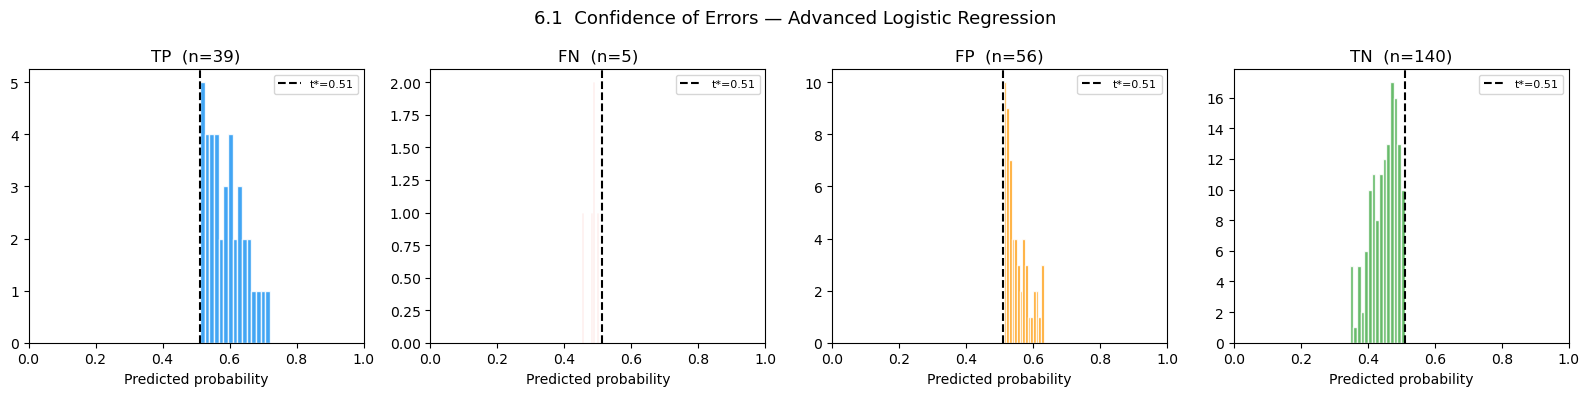

In [51]:
from sklearn.metrics import recall_score as _recall_score

# ── Setup ─────────────────────────────────────────────────────────────────
X_val_r = X_val.reset_index(drop=True)
y_val_r  = y_val.reset_index(drop=True)

t_star_adv      = apply_cost_threshold(y_val_r, y_val_prob_adv)
y_pred_adv_cost = (y_val_prob_adv >= t_star_adv).astype(int)

def label_outcome(y_true, y_pred):
    out = []
    for t, p in zip(y_true, y_pred):
        if   t==1 and p==1: out.append('TP')
        elif t==1 and p==0: out.append('FN')
        elif t==0 and p==1: out.append('FP')
        else:               out.append('TN')
    return np.array(out)

outcome = label_outcome(y_val_r, y_pred_adv_cost)
tn, fp, fn, tp = confusion_matrix(y_val_r, y_pred_adv_cost).ravel()
print(f"t* = {t_star_adv:.3f}  |  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

# ── 6.1  Confidence of errors ──────────────────────────────────────────────
group_colors = {'TP': '#2196F3', 'FN': '#F44336', 'FP': '#FF9800', 'TN': '#4CAF50'}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, g in zip(axes, ['TP', 'FN', 'FP', 'TN']):
    probs = y_val_prob_adv[outcome == g]
    ax.hist(probs, bins=15, color=group_colors[g], edgecolor='white', alpha=0.85)
    ax.axvline(t_star_adv, color='black', ls='--', lw=1.5, label=f't*={t_star_adv:.2f}')
    ax.set_title(f'{g}  (n={len(probs)})')
    ax.set_xlabel('Predicted probability')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
plt.suptitle('6.1  Confidence of Errors — Advanced Logistic Regression', fontsize=13)
plt.tight_layout()
plt.show()

**6.1 Interpretation**

The model gives each applicant a risk score between 0 and 1. Anyone above 0.511 gets flagged for manual review.

The 5 defaults we missed got scores of 0.453–0.501 — just barely below the cutoff. The model wasn't confidently wrong about them; it genuinely wasn't sure and scored them just slightly too low to flag. If we lowered the cutoff from 0.511 to, say, 0.44, we would recover all 5 missed defaults — but we'd also flag too many extra applicants and blow past the 40% review capacity we derived from staffing.

So these 5 misses aren't a fundamental flaw. They're the direct consequence of the operational limit we set: with a fixed review budget, some borderline cases will always fall just below the cutoff.

Also worth noting: the model never assigns very high or very low scores. The highest score in the entire validation set is 0.72, the lowest is 0.35 — everyone stays close to 0.5. This is because during training we used heavy regularisation (C=0.001) to prevent overfitting on our small dataset of 960 training samples, which flattens all probability outputs toward the centre.

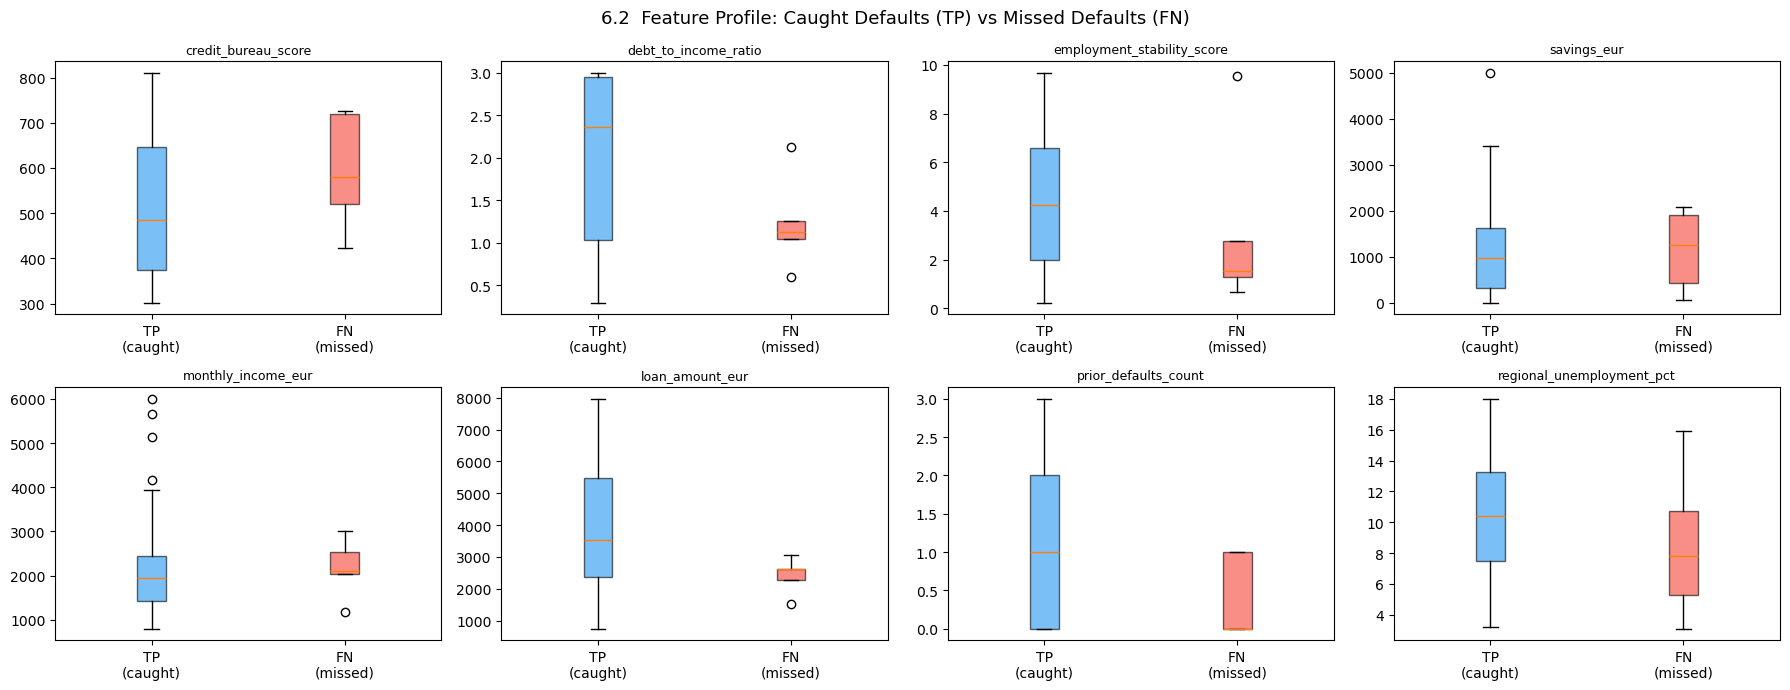

In [52]:
key_features = ['credit_bureau_score', 'debt_to_income_ratio',
                'employment_stability_score', 'savings_eur',
                'monthly_income_eur', 'loan_amount_eur',
                'prior_defaults_count', 'regional_unemployment_pct']

def feature_boxplot(mask, groups, labels, colors, title):
    subset = X_val_r[mask].copy().reset_index(drop=True)
    subset['group'] = outcome[mask]
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    axes = axes.flatten()
    for ax, feat in zip(axes, key_features):
        data = [subset[subset['group'] == g][feat].values for g in groups]
        bp = ax.boxplot(data, patch_artist=True, tick_labels=labels)
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.6)
        ax.set_title(feat, fontsize=9)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

feature_boxplot(y_val_r.values == 1,
                ['TP', 'FN'], ['TP\n(caught)', 'FN\n(missed)'],
                ['#2196F3', '#F44336'],
                '6.2  Feature Profile: Caught Defaults (TP) vs Missed Defaults (FN)')

**6.2 Interpretation**

The 5 defaults the model missed don't look like typical defaulters. Compare them to the 39 it caught:

- They have almost no history of previous defaults (0.25 average vs 1.09 for caught defaults) — no warning sign in their credit file
- Their debt relative to income is much lower (DTI 1.17 vs 1.91) — they're not financially overextended
- They earn more (€2,498 vs €2,184/month) and hold more savings (€1,514 vs €1,194)

To the model — and frankly to any loan officer reading their application — these people look like reasonable borrowers. They probably defaulted because something unexpected happened *after* the loan was approved: losing a job, a medical emergency, a business that went under. That kind of sudden life event doesn't leave any trace in the 13 features we measure at application time.

This is why the model fails on these specific cases: it can only see the financial snapshot from the application form. It has no way of knowing what will happen to that person six months later.

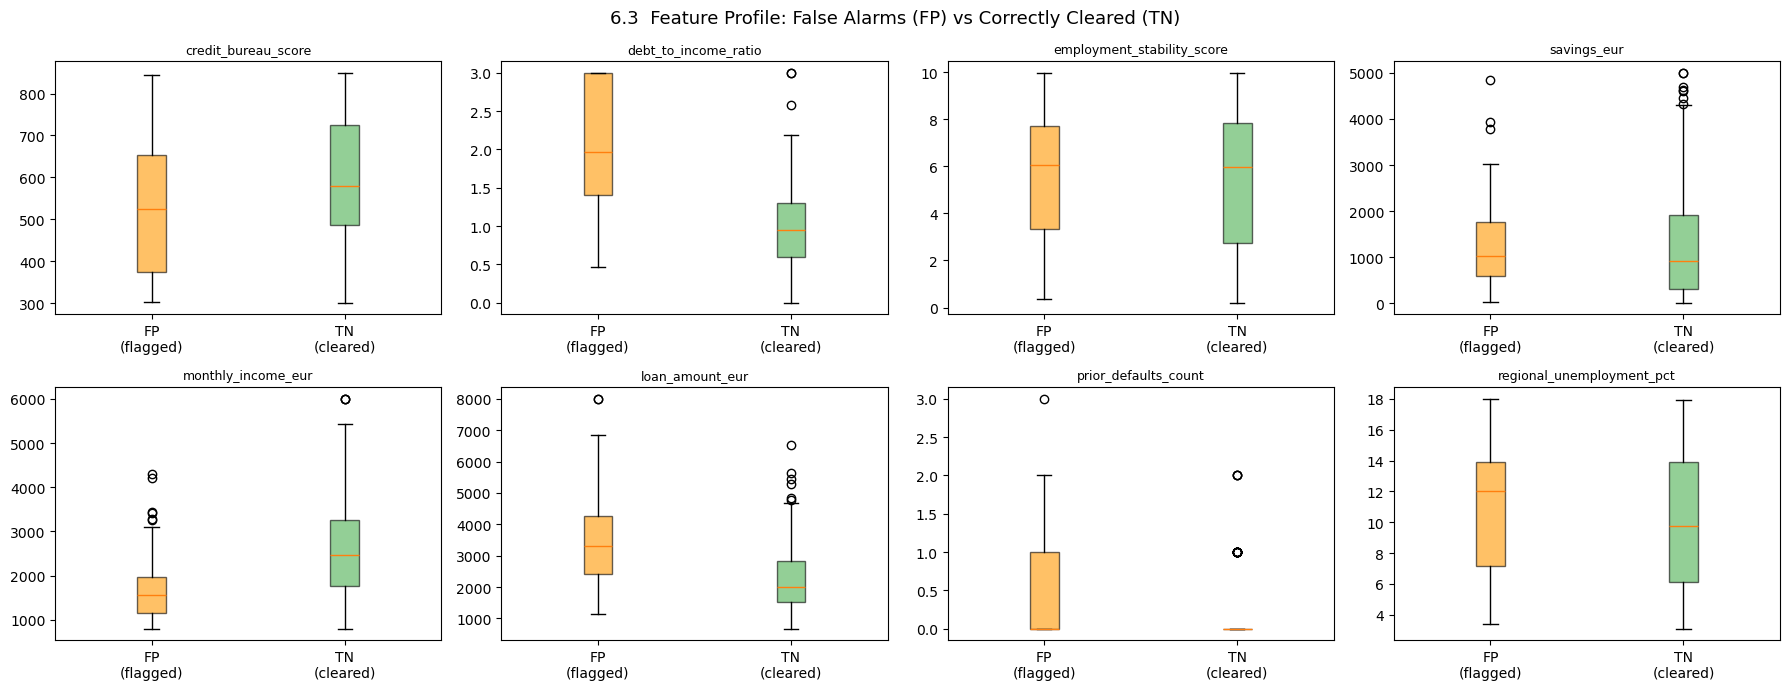

In [53]:
feature_boxplot(y_val_r.values == 0,
                ['FP', 'TN'], ['FP\n(flagged)', 'TN\n(cleared)'],
                ['#FF9800', '#4CAF50'],
                '6.3  Feature Profile: False Alarms (FP) vs Correctly Cleared (TN)')

**6.3 Interpretation**

The 56 good borrowers we unnecessarily flagged share a recognisable profile: they applied for large loans (€3,538 on average vs €2,342 for non-flagged applicants), they earn significantly less (€1,777 vs €2,650/month), and as a result their debt-to-income ratio is roughly double (2.0 vs 1.0). They also tend to have lower credit scores and more prior credit issues.

In plain terms: they look risky on paper, and the model is correct to be suspicious — it just happens to be wrong about these specific individuals. They took on large loans relative to their income, have a spotty credit history, and yet they paid back without defaulting.

Flagging them is still the right call. Missing a real default costs €2,000; reviewing a false alarm costs €100. So the model should flag anyone who looks this risky and leave the final decision to a human reviewer who can pick up on things a model cannot — like how the applicant communicates, whether their business plan is credible, or whether their income situation has recently changed.

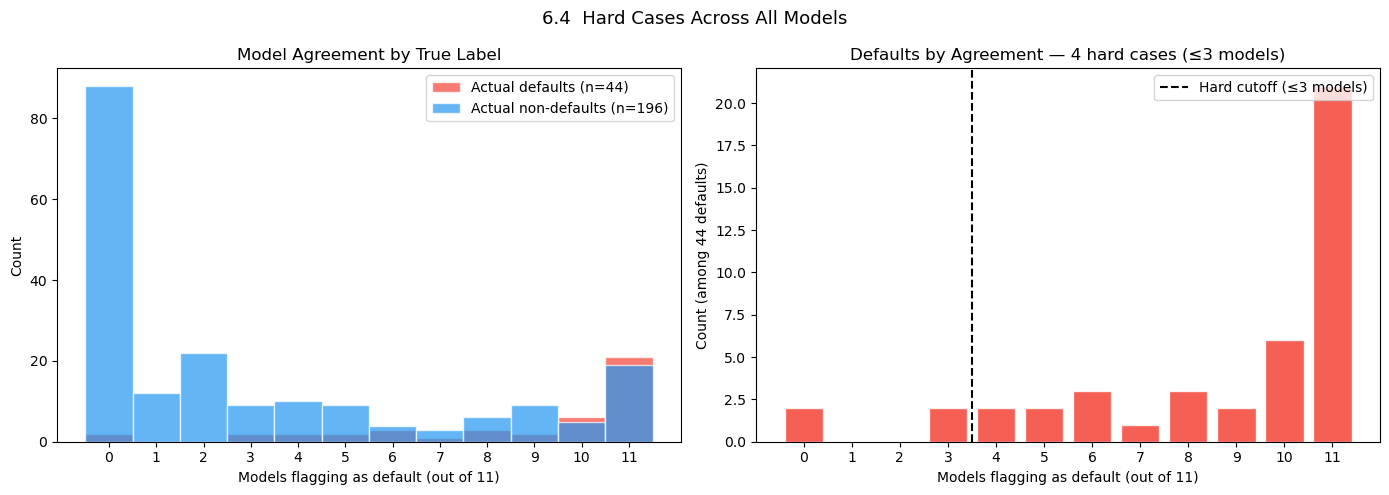


Feature means — hard cases vs all defaults:
                            Hard cases (n=4)  All defaults (n=44)
applicant_age                          37.50                45.41
monthly_income_eur                   2498.08              2183.50
loan_amount_eur                      2982.42              3722.23
debt_to_income_ratio                    1.17                 1.91
employment_stability_score              3.14                 4.17
prior_defaults_count                    0.25                 1.09
credit_bureau_score                   511.70               519.65
sector_risk_index                       2.75                 3.00
regional_unemployment_pct               8.45                10.22
savings_eur                          1513.82              1193.10
num_active_credit_lines                 2.75                 2.70
declared_address_match                  0.75                 0.84
application_quarter                     2.50                 2.50


In [54]:
all_probs = [y_val_prob_base, y_val_prob_adv, y_val_prob_nb, y_val_prob_lda,
             y_val_prob_knn, y_val_prob_dt, y_val_prob_rf, y_val_prob_xgb,
             y_val_prob_ada_dt, y_val_prob_ada_lr, y_val_prob_bag_knn]

all_preds_matrix = np.column_stack([
    (p >= apply_cost_threshold(y_val_r, p)).astype(int) for p in all_probs
])
agreement = all_preds_matrix.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for is_def, label, color in [(True, 'Actual defaults (n=44)', '#F44336'),
                              (False, 'Actual non-defaults (n=196)', '#2196F3')]:
    m = y_val_r.values == (1 if is_def else 0)
    axes[0].hist(agreement[m], bins=range(13), color=color, edgecolor='white',
                 alpha=0.7, align='left', label=label)
axes[0].set_xlabel('Models flagging as default (out of 11)')
axes[0].set_ylabel('Count')
axes[0].set_title('Model Agreement by True Label')
axes[0].set_xticks(range(12))
axes[0].legend()

hard_cutoff = 3
default_agreement = agreement[y_val_r.values == 1]
n_hard = (default_agreement <= hard_cutoff).sum()
counts = pd.Series(default_agreement).value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color='#F44336', edgecolor='white', alpha=0.85)
axes[1].axvline(hard_cutoff + 0.5, color='black', ls='--', lw=1.5,
                label=f'Hard cutoff (≤{hard_cutoff} models)')
axes[1].set_xlabel('Models flagging as default (out of 11)')
axes[1].set_ylabel('Count (among 44 defaults)')
axes[1].set_title(f'Defaults by Agreement — {n_hard} hard cases (≤{hard_cutoff} models)')
axes[1].set_xticks(range(12))
axes[1].legend()
plt.suptitle('6.4  Hard Cases Across All Models', fontsize=13)
plt.tight_layout()
plt.show()

hard_mask = (y_val_r.values == 1) & (agreement <= hard_cutoff)
if hard_mask.sum() > 0:
    comp = pd.DataFrame({
        f'Hard cases (n={hard_mask.sum()})': X_val_r[hard_mask].mean(),
        'All defaults (n=44)':              X_val_r[y_val_r.values == 1].mean()
    }).round(2)
    print(f"\nFeature means — hard cases vs all defaults:")
    print(comp)

**6.4 Interpretation**

4 out of 44 defaults (9%) were flagged by 3 or fewer of the 11 models — meaning virtually every model agreed these people looked like safe borrowers. They all turned out to be wrong.

What do these 4 people look like?
- Almost no prior defaults (0.25 average) — clean credit history
- Low debt relative to income (DTI 1.17) — not financially stretched
- Higher income than the typical defaulter (€2,498/month) and more savings (€1,514)

By every standard credit metric, they look like responsible borrowers. The model isn't failing because it's poorly designed — it's failing because there is genuinely no signal in the data that these people are risky.

These cases represent a hard ceiling: **you cannot catch these defaults with better algorithms or more model tuning**. The 13 features in the application form simply don't contain enough information to predict what will make these particular people default. To catch them you would need different data entirely — real-time cash flow monitoring, employment stability tracking, or information about major life events — none of which appears in a standard loan application form.

This is an honest and important finding. Any credit scoring system, no matter how sophisticated, will face this same 9% ceiling as long as it is trained only on application-time data.

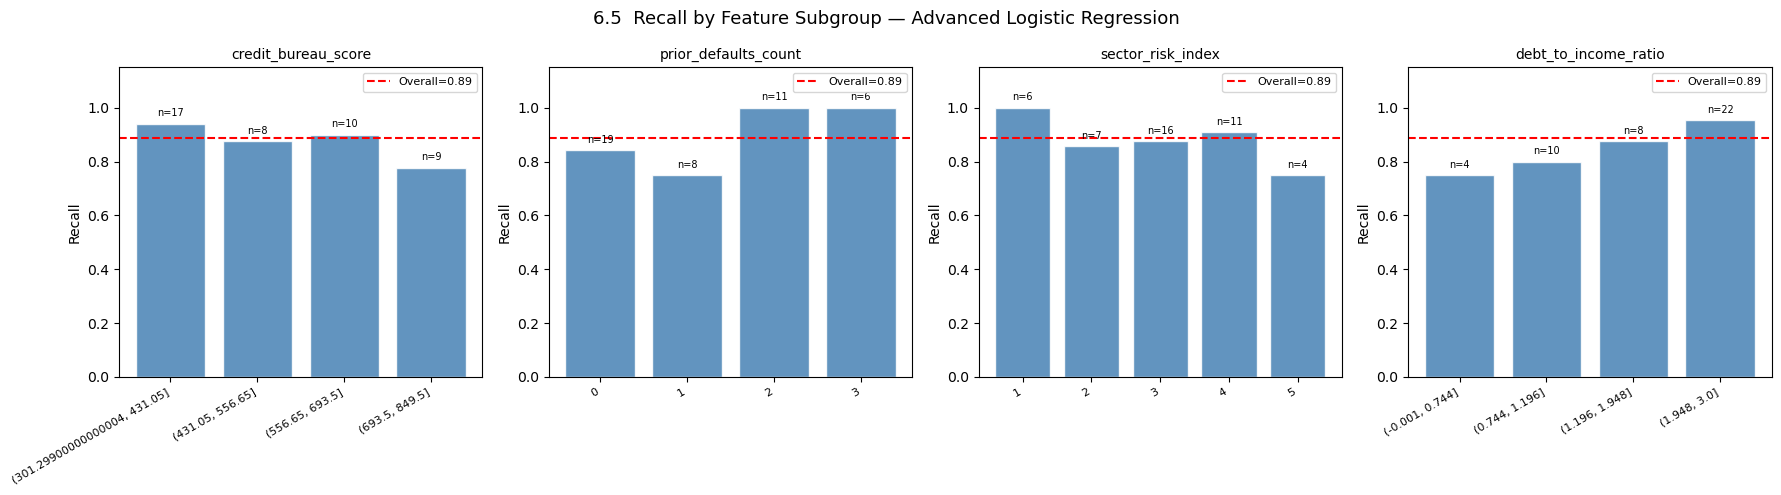

In [55]:
subgroup_feats = ['credit_bureau_score', 'prior_defaults_count',
                  'sector_risk_index', 'debt_to_income_ratio']
overall_recall = _recall_score(y_val_r, y_pred_adv_cost)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feat in zip(axes, subgroup_feats):
    col = X_val_r[feat]
    bins = col.astype(int) if col.nunique() <= 5 else pd.qcut(col, q=4, duplicates='drop')
    df_s = pd.DataFrame({'bin': bins, 'true': y_val_r.values, 'pred': y_pred_adv_cost})
    rec = (df_s[df_s['true'] == 1]
           .groupby('bin', observed=True)
           .apply(lambda g: g['pred'].sum() / len(g), include_groups=False))
    sup = df_s[df_s['true'] == 1].groupby('bin', observed=True).size()
    bars = ax.bar(range(len(rec)), rec.values, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axhline(overall_recall, color='red', ls='--', lw=1.5, label=f'Overall={overall_recall:.2f}')
    ax.set_xticks(range(len(rec)))
    ax.set_xticklabels([str(b) for b in rec.index], rotation=30, ha='right', fontsize=8)
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    for bar, (_, n) in zip(bars, sup.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={n}', ha='center', va='bottom', fontsize=7)
plt.suptitle('6.5  Recall by Feature Subgroup — Advanced Logistic Regression', fontsize=13)
plt.tight_layout()
plt.show()

**6.5 Interpretation**

The bars show how well the model catches defaults depending on the applicant's characteristics. The red dashed line is the overall recall (88.6%).

**Debt-to-income ratio** — the clearest pattern: recall rises from 75% (low-debt applicants) to 95% (high-debt applicants). When someone's debt is clearly manageable relative to their income, the model considers them low-risk and may miss them even if they default. When debt is high, the model correctly flags them. This is why the missed defaults in 6.2 have DTI ≈ 1.17 — they're in the bottom quartile where the model is weakest.

**Credit bureau score** — recall drops from 94% for low-score applicants (≤431) to 78% for high-score applicants (>694). When the credit bureau says someone is reliable, the model agrees — and is wrong 22% of the time for that group. A high credit score hides risk that will only show up later.

**Prior defaults count** — the model catches 100% of defaults among applicants with 2 or 3 prior defaults. These are obvious cases. The weakest group is applicants with exactly 1 prior default (75%), not 0. Surprisingly, having zero defaults is not the hardest case — the model still catches 84% of first-time defaulters.

**Sector risk index** — broadly stable across sectors. Sector 5 shows 75% but only has 4 defaults, so this number is not reliable.

The consistent pattern across all four features: **the model is good at spotting obvious risk (high debt, multiple prior defaults) and poor at catching people who look financially solid on paper**. The same story as 6.2, 6.3, and 6.4.

## 7. Conclusion